# Sistema Inteligente de Gestión de Reuniones (RAG + Agente)
### Trabajo Práctico N°2 — Sistemas Inteligentes con RAG o Agentes
**Materia:** Inteligencia Artificial — Ingeniería en Sistemas de Información

**Integrantes:** Juan Pablo Jaca, Nahuel Berli, Gustavo Giampietro, Alexis Mateo, Juan Cruz Mondino

**Caso de negocio:** un asistente que, a partir del audio de una reunión de trabajo,
transcribe lo hablado, genera un resumen (con gráficos/mapa conceptual), permite
consultar en lenguaje natural lo charlado (RAG) y completa automáticamente una
planilla de reunión según Norma ISO 9001 para que el responsable solo la revise.


## Índice
1. Instalación y configuración
2. Módulo de Transcripción (Speech-to-Text)
3. Módulo de Resumen y Visualización (texto + mapa conceptual)
4. Módulo RAG (indexación y consultas sobre la reunión)
5. Módulo de Completado de Planilla (ISO 9001)
6. Orquestación — Agente principal (Langchain)
7. Casos de prueba
8. Conclusiones y dificultades (defensa oral)


## ¿Qué es Groq? ¿Por qué se elige un LLM en este tipo de proyectos?

**Groq** es una empresa que ofrece inferencia de modelos de lenguaje a través de una API, con hardware propio (chips LPU, *Language Processing Unit*) diseñado para generar texto a muy alta velocidad. **Groq no crea el modelo**: aloja modelos abiertos. En este notebook se usa `openai/gpt-oss-120b`, un modelo de pesos abiertos de 120 mil millones de parámetros. Se accede con `ChatGroq` (del paquete `langchain-groq`) y una API key (`GROQ_API_KEY`).

Se configura con `temperature=0` para que las respuestas sean lo más determinísticas posible. Esto importa cuando se generan JSON estructurados (mapa conceptual, planilla) o respuestas que deben basarse en la reunión.

**¿Por qué un LLM en este proyecto?** Porque las tareas centrales requieren comprender lenguaje natural, algo que las reglas fijas no resuelven:

| Módulo | Tarea que resuelve el LLM |
|---|---|
| Resumen | Sintetizar la transcripción y deducir el puesto de cada persona |
| Mapa conceptual | Extraer temas y relaciones en formato JSON |
| RAG | Redactar la respuesta a partir de los fragmentos recuperados |
| Planilla ISO 9001 | Extraer fecha, asistentes, acuerdos y plazos con salida estructurada |

**¿Por qué Groq en particular?** Ofrece un plan gratuito y baja latencia. La contrapartida es que ese plan tiene límites de tokens por minuto y por solicitud. Por eso el notebook divide la transcripción en fragmentos (*map-reduce*), limita el historial del chat (`MAX_MENSAJES_HISTORIAL`) y, en la variante B, le pasa a la planilla el resumen en lugar de la transcripción completa.

## ¿Qué es un framework LangChain? ¿Cómo se utiliza a lo largo del notebook?

**LangChain** es un framework para construir aplicaciones sobre LLMs. Provee componentes estándar (plantillas de prompts, modelos, parsers, divisores de texto, bases vectoriales, herramientas y agentes) que se combinan entre sí. Permite cambiar de proveedor sin reescribir el pipeline: el proyecto pasó de OpenAI a Gemini y luego a Groq, y el resto del código casi no cambió.

Su idea central es la **cadena** (*chain*), que se arma con el operador `|` y encadena pasos: `prompt | llm | parser`.

**Uso en cada módulo:**

| Componente de LangChain | Dónde se usa | Función |
|---|---|---|
| `ChatGroq`, `CohereEmbeddings` | Configuración, módulo 4 | Conectan el LLM y el modelo de embeddings |
| `ChatPromptTemplate` | Módulos 3, 4, 5 y chat | Plantillas de prompt con variables (`{texto}`, `{contexto}`, `{pregunta}`) |
| `StrOutputParser` | Módulos 3 y 4 | Convierte la respuesta del modelo en un `str` |
| `RecursiveCharacterTextSplitter` | Módulos 3 y 4 | Divide texto en fragmentos (*chunks*) con solapamiento |
| `Document` + `FAISS` | Módulo 4 | Guardan los fragmentos con sus vectores y metadata (hablante, minuto) |
| `as_retriever(k=4)` | Módulo 4 y chat | Recupera los 4 fragmentos más parecidos a la pregunta |
| `with_structured_output` + Pydantic | Módulo 5 | Fuerza al LLM a devolver la planilla con el esquema `PlanillaReunionISO9001` |
| `MessagesPlaceholder`, `HumanMessage`, `AIMessage` | Interfaz de chat | Manejan el historial de la conversación |
| `@tool` y `create_agent` | Módulo 6 | Exponen `ConsultarReunion` y `CompletarPlanilla` como herramientas de un agente |

En el resumen se aplica el patrón **map-reduce**: se resume cada fragmento (*map*) y luego se unifican esos resúmenes en uno solo (*reduce*). El módulo RAG usa el flujo clásico *retrieval → contexto → generación*.

## ¿Qué son los embeddings y por qué se importan desde Cohere? ¿Qué función tienen en el proyecto?

Un **embedding** es la representación de un texto como un vector de números. Textos con significado parecido quedan cerca en ese espacio vectorial, aunque no compartan las mismas palabras. Por ejemplo, "problemas de producción" y "fallas en la línea de fabricación" tendrán vectores cercanos. Esto permite hacer **búsqueda semántica** en lugar de búsqueda por palabras clave.

**¿Por qué Cohere?** Un LLM de chat (como el de Groq) genera texto, pero no es un modelo de embeddings. Se necesita un modelo distinto y el proyecto usa el de Cohere:

- La clase `CohereEmbeddings` (del paquete `langchain-cohere`) se conecta a la API de Cohere con `COHERE_API_KEY`.
- El modelo elegido es `embed-v4.0`, multilingüe, lo que es importante porque la reunión está en español.
- Cohere ofrece un plan gratuito de prueba, adecuado para un trabajo académico.

**Función en el proyecto (módulo RAG):**

1. **Indexación:** cada fragmento de la transcripción se convierte en un vector y se guarda en **FAISS**, junto con su metadata (`hablante`, `minuto`).
2. **Consulta:** la pregunta del usuario se convierte en un vector con el mismo modelo.
3. **Recuperación:** FAISS busca los `k=4` fragmentos con vectores más cercanos al de la pregunta.
4. **Generación:** esos fragmentos se pasan como contexto al LLM, que responde usando solo esa información.

Así el LLM no necesita recibir la transcripción completa, lo que ahorra tokens y reduce las respuestas inventadas.

## 1. Instalación y configuración

In [ ]:
!pip install -q langchain langchain-community langchain-groq \
    langchain-cohere langchain-text-splitters \
    faiss-cpu networkx matplotlib python-dotenv pydantic \
    python-docx whisperx==3.8.6 gradio==5.50.0

^C



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## ¿Qué es ffmpeg? ¿Por qué hay que instalarlo en la computadora? ¿Qué función tiene en el proyecto?

**FFmpeg** es un programa de línea de comandos para leer, convertir y procesar audio y video en casi cualquier formato (mp3, wav, mp4, etc.).

**Función en el proyecto:** cuando se ejecuta `whisperx.load_audio(ruta_audio)`, WhisperX invoca internamente `ffmpeg` para decodificar el archivo de audio (en este caso un `.mp3`) y convertirlo a lo que Whisper necesita: una señal **mono a 16 kHz**. Sin ese paso, el modelo no puede leer el audio.

**¿Por qué se instala aparte?** Porque ffmpeg **no es una librería de Python**: es un programa del sistema operativo. `pip install` no lo instala, y WhisperX lo llama como un comando externo. Para que funcione tiene que estar instalado y accesible desde el `PATH` del sistema. PowerShell es solo la herramienta desde la que se instala y se verifica:

- Instalación en Windows: `winget install ffmpeg` (o `choco install ffmpeg`).
- Verificación: `ffmpeg -version`.
- Si no está instalado, `load_audio` falla con un error tipo `FileNotFoundError`.

En Google Colab no hace falta instalarlo porque ya viene incluido.

In [ ]:
!winget install ffmpeg

In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_cohere import CohereEmbeddings
import json

load_dotenv(override=True)

# --- LLM: Groq ---
if not os.getenv("GROQ_API_KEY"):
    import getpass
    os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ_API_KEY: ")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

# --- Embeddings: Cohere ---
if not os.getenv("COHERE_API_KEY"):
    import getpass
    os.environ["COHERE_API_KEY"] = getpass.getpass("COHERE_API_KEY: ")

# --- HF para WhisperX ---
if not os.getenv("HF_TOKEN"):
    import getpass
    os.environ["HF_TOKEN"] = getpass.getpass("HF_TOKEN: ")

# --- Rutas ---
RUTA_AUDIO = "Simulación de Reunión de Trabajo - UPN.mp3"
RUTA_PLANILLA_SALIDA = "output/planilla_reunion.docx"
RUTA_PLANTILLA_MINUTA = "Minuta de Reunión.docx"
RUTA_TRANSCRIPCION = "output/transcripcion.txt"
RUTA_TRANSCRIPCION1 = "output/transcripcion1.txt"
RUTA_MAPA_CONCEPTUAL = "output/mapa_conceptual_reunion.png"
RUTA_RESUMEN = "output/resumen_reunion.txt"

RUTA_TRANSCRIPCION_JSON = "output/transcripcion1.json"
RUTA_RESUMEN1 = "output/resumen_reunion1.txt"
RUTA_MAPA_CONCEPTUAL1 = "output/mapa_conceptual_reunion1.png"
RUTA_RESPUESTA_RAG = "output/respuesta_rag.txt"
RUTA_RESPUESTA_RAG1 = "output/respuesta_rag1.txt"
RUTA_PLANILLA_SALIDA1 = "output/planilla_reunion1.docx"

## 2. Módulo de Transcripción (Speech-to-Text)
Convierte el audio de la reunión en texto. Candidato: `whisper` / `faster-whisper`.
Pendiente definir si se agrega diarización (identificar quién habla) — no es
requisito del caso de negocio pero podría enriquecer la planilla (participantes).


## ¿Qué es WhisperX y cómo funciona en el notebook?

**WhisperX** es una herramienta de código abierto construida sobre **Whisper** (el modelo de reconocimiento de voz de OpenAI). Agrega lo que Whisper solo no ofrece:

- **Transcripción rápida por lotes**, mediante `faster-whisper`.
- **VAD** (*Voice Activity Detection*), que detecta dónde hay voz para segmentar el audio.
- **Alineación** palabra por palabra con marcas de tiempo precisas.
- **Diarización** (quién habla y cuándo), mediante `pyannote`.

**Flujo de la función `transcribir_audio`:**

| Paso | Instrucción | Qué hace |
|---|---|---|
| 1 | `load_model` | Carga el modelo Whisper (`small` en la primera versión, `large-v3` en la mejorada) |
| 2 | `load_audio` | Decodifica el mp3 a un arreglo de audio de 16 kHz mono (usa ffmpeg) |
| 3 | `transcribe` | Genera los segmentos de texto |
| 4 | `load_align_model` + `align` | Ajusta los tiempos de cada palabra |
| 5 | `DiarizationPipeline` + `assign_word_speakers` | Asigna un hablante a cada segmento |
| 6 | Armado del resultado | Genera `Persona 1: ...`, `Persona 2: ...` |

**Configuración relevante:**

- `device` y `compute_type` se eligen automáticamente: GPU con `float16` si hay CUDA, o CPU con `int8`.
- `HF_TOKEN` (token de Hugging Face) es obligatorio porque los modelos de diarización de pyannote requieren aceptar sus condiciones de uso.
- La versión mejorada fija `language="es"` para evitar errores de detección de idioma y usa `large-v3`, que da mucha mejor calidad.
- Antes de cargar la alineación y la diarización se libera la memoria de la GPU (`del modelo` y `torch.cuda.empty_cache()`), para evitar errores de memoria (OOM) con el modelo grande.

Los archivos que se generan (`transcripcion1.txt` y `transcripcion1.json`) alimentan los módulos de resumen, RAG y planilla.

## ¿Por qué se generan un `.txt` y un `.json`? ¿Qué mejoras aporta?

La función `transcribir_audio` devuelve la misma transcripción en dos formatos, porque cada módulo del proyecto necesita algo distinto:

| Archivo | Contenido | Quién lo usa |
|---|---|---|
| `transcripcion1.txt` | Texto plano con formato `Persona N: ...` | Resumen, mapa conceptual y planilla, que solo necesitan que el LLM lea el texto |
| `transcripcion1.json` | Lista de turnos con `hablante`, `inicio`, `fin` y `texto` | Módulo RAG (`crear_vectorstore`) y cálculo de la duración de la reunión |

### Mejoras que aporta el JSON

**1. Metadata de hablante y minuto en el RAG.**
`crear_vectorstore` agrupa los turnos consecutivos de una misma persona con `groupby`. Cada documento queda con `metadata={"hablante": ..., "minuto": ...}`. Al recuperar fragmentos, el contexto que recibe el LLM se ve así: `[Persona 2 · minuto 5]`. Esto permite responder **quién dijo qué y cuándo**, por ejemplo: *"¿Qué personas tienen tareas asignadas?"*.

**2. Fragmentos con sentido.**
Con el `.txt`, `RecursiveCharacterTextSplitter` corta cada 1000 caracteres, sin importar dónde termina cada intervención, por lo que puede partir una idea a la mitad. Con el JSON, cada documento es un turno de habla completo.

**3. Duración exacta de la reunión.**
`planilla1.duracion_min` se calcula a partir de los tiempos reales: `(turnos[-1]["fin"] - turnos[0]["inicio"]) / 60`. Con el `.txt` no hay marcas de tiempo, así que la duración la estima el LLM y puede ser inexacta.

**4. Datos estructurados sin volver a procesar texto.**
El JSON conserva los datos originales (tiempos y hablantes) sin tener que interpretarlos desde un string. Es la base para futuras mejoras, como filtrar por persona o por tramo de la reunión.

### ¿Por qué se conserva también el `.txt`?
El resumen, el mapa conceptual y la planilla trabajan sobre texto corrido, por lo que el `.txt` es el formato natural para pasárselo al LLM. Además, permite comparar los dos enfoques del RAG: la **variante A** (texto plano, sin metadata) y la **variante B** (turnos con hablante y minuto).

## Bloque de transcripción: `batch_size`, `vad_options`, alineación, diarización, diagnóstico y texto por hablante

### `batch_size`
Cantidad de segmentos de audio que el modelo procesa **en paralelo** en cada pasada. Un valor mayor acelera la transcripción pero consume más memoria (VRAM en GPU o RAM). Un valor menor es más lento y usa menos memoria. **Solo afecta la velocidad, no la calidad ni la cantidad de texto transcrito.**

### `vad_options`
El **VAD** (*Voice Activity Detection*) separa lo que es voz de lo que es silencio o ruido, y así define qué trozos de audio se envían a Whisper. Se ajusta con dos umbrales:

- `vad_onset`: probabilidad mínima para considerar que **empieza** un tramo de voz.
- `vad_offset`: probabilidad mínima para considerar que **termina**.

Valores más bajos hacen al detector más sensible: capta voces suaves, superpuestas o lejanas, pero puede incluir más ruido. En el código está comentado un ejemplo (`0.2` y `0.25`) para usar cuando se pierden fragmentos de audio.

### Alineación (`load_align_model` + `align`)
Whisper entrega tiempos aproximados por segmento. La alineación usa un modelo de fonemas (wav2vec2) específico del idioma para calcular el **inicio y fin exactos de cada palabra**. Es necesaria para la diarización, porque permite decidir a qué hablante corresponde cada palabra, incluso cuando dos personas se turnan dentro de un mismo segmento.

### Diarización (`DiarizationPipeline` + `assign_word_speakers`)
Responde a la pregunta **¿quién habló y cuándo?**. El modelo de pyannote detecta a los hablantes por sus rasgos de voz y devuelve intervalos etiquetados (`SPEAKER_00`, `SPEAKER_01`, ...). Luego `assign_word_speakers` cruza esos intervalos con el tiempo de cada palabra y les asigna hablante. En la versión mejorada, `num_hablantes=5` fija `min_speakers` y `max_speakers` para que el modelo no invente ni pierda personas.

### Diagnóstico
Imprime métricas para verificar que **no se haya perdido audio**:

- Duración total del audio.
- Segundo en que termina el último segmento transcrito.
- Tiempo total con voz transcrita.
- Cantidad de segmentos y de palabras, y palabras por minuto.

Si el último segmento termina mucho antes que el audio, o las palabras por minuto son muy bajas, probablemente el VAD está descartando voz y conviene ajustar `vad_options`.

### Texto por hablante
Los identificadores internos de pyannote se reemplazan por etiquetas legibles (`Persona 1`, `Persona 2`, ...) en orden de aparición. La función `nombre()` asigna `SPEAKER_DESCONOCIDO` cuando un segmento no tiene hablante (`None`). Con eso se construyen:

- `turnos`: lista de diccionarios con `hablante`, `inicio`, `fin` y `texto`. Se guarda como JSON y el módulo RAG lo usa para indexar con metadata de hablante y minuto; también sirve para calcular la duración de la reunión.
- `texto`: la transcripción con formato `Persona N: ...`, guardada en `.txt`, que consumen el resumen y la planilla.
- `stats`: las métricas del diagnóstico.

In [16]:
import torch
import whisperx

def transcribir_audio(ruta_audio: str, tamanio_modelo: str = "small") -> str:
    """
    Transcribe el audio y separa el texto por hablante.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    compute_type = "float16" if device == "cuda" else "int8"

    # --- Transcripción ---
    modelo = whisperx.load_model(
        tamanio_modelo,
        device,
        compute_type=compute_type
    )

    audio = whisperx.load_audio(ruta_audio)

    resultado = modelo.transcribe(
        audio,
        batch_size=16                       # Modificar para que transcriba mas
    )

    # --- Alineación ---
    modelo_align, metadata = whisperx.load_align_model(
        language_code=resultado["language"],
        device=device
    )

    resultado = whisperx.align(
        resultado["segments"],
        modelo_align,
        metadata,
        audio,
        device
    )

    # --- Diarización ---
    diarizador = whisperx.diarize.DiarizationPipeline(
        token=os.environ["HF_TOKEN"],
        device=device
    )

    segmentos_hablantes = diarizador(audio)

    resultado = whisperx.assign_word_speakers(
        segmentos_hablantes,
        resultado
    )

    # --- Texto por hablante ---
    etiquetas_por_hablante = {}
    lineas = []

    for segmento in resultado["segments"]:
        hablante_raw = segmento.get(
            "speaker",
            "SPEAKER_DESCONOCIDO"
        )

        if hablante_raw not in etiquetas_por_hablante:
            etiquetas_por_hablante[hablante_raw] = (
                f"Persona {len(etiquetas_por_hablante) + 1}"
            )

        lineas.append(
            f"{etiquetas_por_hablante[hablante_raw]}: "
            f"{segmento['text'].strip()}"
        )

    return "\n".join(lineas)

In [17]:
os.makedirs("output", exist_ok=True)

print("Iniciando transcripción...")
transcripcion = transcribir_audio(RUTA_AUDIO)

with open(RUTA_TRANSCRIPCION, "w", encoding="utf-8") as f:
    f.write(transcripcion)

print("Transcripción finalizada.")
print(f"Guardada en: {RUTA_TRANSCRIPCION}")

print("\n--- TRANSCRIPCIÓN ---\n")
print(transcripcion)

Iniciando transcripción...


c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\venv\lib\site-packages\pyannote\audio\core\io.py:48: UserWarning: 
torchcodec is not installed correctly so built-in audio decoding will fail. Solutions are:
* use audio preloaded in-memory as a {'waveform': (channel, time) torch.Tensor, 'sample_rate': int} dictionary;
* fix torchcodec installation. Error message was:

Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6 and 7.
          2. The PyTorch version (2.8.0+cpu) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.
        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpe

2026-09-30 13:21:53 - whisperx.asr - INFO - No language specified, language will be detected for each audio file (increases inference time)
2026-09-30 13:21:53 - whisperx.vads.pyannote - INFO - Performing voice activity detection using Pyannote...


Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.6. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\venv\lib\site-packages\whisperx\assets\pytorch_model.bin`


2026-09-30 13:22:21 - whisperx.asr - INFO - Detected language: es (0.89) in first 30s of audio
2026-09-30 13:27:04 - whisperx.diarize - INFO - Loading diarization model: pyannote/speaker-diarization-community-1


c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\venv\lib\site-packages\pyannote\audio\models\blocks\pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  std = sequences.std(dim=-1, correction=1)


Transcripción finalizada.
Guardada en: output/transcripcion.txt

--- TRANSCRIPCIÓN ---

Persona 1: Muy buenas noches con todos ustedes, mi nombre es Elen Contreras, soy gerente general de la empresa Pesquera Diamante.
Persona 1: Todos ustedes han sido convocados y convocadas a esta reunión de gerencia muy importante por los cambios que van a venir aquí en Adelante.
Persona 1: Para los que recién están ingresando aquí a la empresa, les voy a explicar brevemente en qué consiste el trabajo que realizamos.
Persona 1: Nosotros somos una especie de empresa dedicada al procesamiento de harina y aceite de pescado, conserva, productos pescos y congelados.
Persona 1: Tenemos nuestra propia flota de embarcaciones y hemos afrontado esta pandemia saliendo airosos.
Persona 1: Pero sabemos que todo ha cambiado y queremos executivos que no teman a enfrentar estos cambios.
Persona 1: Por eso que ustedes han sido convocados y serán presentados el día de hoy.
Persona 1: Estamos ansiosos de escucharlos.
P

In [18]:
# POSIBLE EJECUCIÓN

from typing import Optional

import torch
import whisperx


def transcribir_audio(
    ruta_audio: str,
    tamanio_modelo: str = "large-v3",          # antes "small": mayor salto de calidad
    idioma: str = "es",
    num_hablantes: Optional[int] = 5,        # pasá 5 si son 5 personas
) -> dict:
    """
    Transcribe, diariza por hablante y devuelve:
      - texto:  transcripción formateada ("Persona N: ...")
      - turnos: lista de dicts (hablante, inicio, fin, texto) para el pipeline LLM
      - stats:  métricas para diagnosticar si falta audio
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    compute_type = "float16" if device == "cuda" else "int8"

    hf_token = os.environ.get("HF_TOKEN")
    if not hf_token:
        raise RuntimeError("Falta la variable de entorno HF_TOKEN (la usa pyannote).")

    # ---------- 1) Transcripción ----------
    modelo = whisperx.load_model(tamanio_modelo, device, compute_type=compute_type)
    audio = whisperx.load_audio(ruta_audio)          # mp3 -> 16 kHz mono
    duracion_audio = len(audio) / 16000

    
    resultado = modelo.transcribe(
        audio,
        language=idioma,                # fija el idioma, evita misdetección
        batch_size=16,                  # solo VELOCIDAD, no cantidad de texto
        #vad_options={"vad_onset": 0.2, "vad_offset": 0.25},
    )

    # Libero VRAM del ASR antes de cargar align + diarización (evita OOM con large)
    del modelo
    if device == "cuda":
        torch.cuda.empty_cache()

    # ---------- 2) Alineación palabra por palabra ----------
    modelo_align, metadata = whisperx.load_align_model(language_code=idioma, device=device)
    resultado = whisperx.align(resultado["segments"], modelo_align, metadata, audio, device)

    # ---------- 3) Diarización ----------
    diarizador = whisperx.diarize.DiarizationPipeline(token=hf_token, device=device)

    try:
        extra = {"min_speakers": num_hablantes, "max_speakers": num_hablantes} if num_hablantes else {}
        segmentos_hablantes = diarizador(audio, **extra)
    except TypeError:
        segmentos_hablantes = diarizador(audio)

    resultado = whisperx.assign_word_speakers(segmentos_hablantes, resultado)

    # ---------- 4) Diagnóstico ----------
    segmentos = resultado["segments"]
    fin_ultimo = segmentos[-1]["end"] if segmentos else 0.0
    duracion_hablada = sum(s["end"] - s["start"] for s in segmentos if s.get("start") is not None)
    total_palabras = sum(len(s["text"].split()) for s in segmentos)

    print(f"Duración del audio:         {duracion_audio:7.1f} s")
    print(f"Último segmento termina en: {fin_ultimo:7.1f} s")
    print(f"Tiempo con voz transcrita:  {duracion_hablada:7.1f} s")
    print(f"Segmentos: {len(segmentos)} | Palabras: {total_palabras} "
          f"({total_palabras / max(duracion_audio / 60, 1e-9):.0f} palabras/min)")

    # ---------- 5) Turnos por hablante ----------
    etiquetas = {}

    def nombre(raw: Optional[str]) -> str:
        key = raw or "SPEAKER_DESCONOCIDO"   # fix: speaker puede venir en None
        if key not in etiquetas:
            etiquetas[key] = f"Persona {len(etiquetas) + 1}"
        return etiquetas[key]

    turnos = [
        {
            "hablante": nombre(s.get("speaker")),
            "inicio": s.get("start"),
            "fin": s.get("end"),
            "texto": s["text"].strip(),
        }
        for s in segmentos
    ]

    texto = "\n".join(f"{t['hablante']}: {t['texto']}" for t in turnos)

    return {
        "texto": texto,
        "turnos": turnos,
        "stats": {
            "duracion_audio": duracion_audio,
            "fin_ultimo_segmento": fin_ultimo,
            "duracion_hablada": duracion_hablada,
            "segmentos": len(segmentos),
            "palabras": total_palabras,
        },
    }


if __name__ == "__main__":
    os.makedirs("output", exist_ok=True)

    print("Iniciando transcripción...")
    salida = transcribir_audio(RUTA_AUDIO, num_hablantes=5)

    # Guardar los artefactos que consumen los bloques 3 a 6
    with open(RUTA_TRANSCRIPCION1, "w", encoding="utf-8") as f:
        f.write(salida["texto"])

    with open(RUTA_TRANSCRIPCION_JSON, "w", encoding="utf-8") as f:
        json.dump(salida["turnos"], f, ensure_ascii=False, indent=2)

    print("Transcripción finalizada.")
    print(f"Guardada en: {RUTA_TRANSCRIPCION1} y {RUTA_TRANSCRIPCION_JSON}")

    print("\n--- TRANSCRIPCIÓN ---\n")
    print(salida["texto"])

Iniciando transcripción...
2026-09-30 13:41:35 - whisperx.asr - INFO - No language specified, language will be detected for each audio file (increases inference time)
2026-09-30 13:41:35 - whisperx.vads.pyannote - INFO - Performing voice activity detection using Pyannote...


Lightning automatically upgraded your loaded checkpoint from v1.5.4 to v2.6.6. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\venv\lib\site-packages\whisperx\assets\pytorch_model.bin`


2026-09-30 14:01:19 - whisperx.diarize - INFO - Loading diarization model: pyannote/speaker-diarization-community-1


c:\Users\Pc\Desktop\Estudios_academicos\Sistemas-2026\IA\TPN2\venv\lib\site-packages\pyannote\audio\models\blocks\pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  std = sequences.std(dim=-1, correction=1)


Duración del audio:           732.5 s
Último segmento termina en:   732.0 s
Tiempo con voz transcrita:    625.0 s
Segmentos: 113 | Palabras: 1526 (125 palabras/min)
Transcripción finalizada.
Guardada en: output/transcripcion1.txt y output/transcripcion1.json

--- TRANSCRIPCIÓN ---

Persona 1: Muy buenas noches con todos ustedes.
Persona 1: Mi nombre es Edwin Contreras, soy gerente general de la empresa Pesquera Diamante.
Persona 1: Todos ustedes han sido convocados y convocadas a esta reunión de gerencia muy importante por los cambios que van a venir aquí en adelante.
Persona 1: Para los que recién están ingresando aquí a la empresa, les voy a explicar brevemente en qué consiste el trabajo que realizamos.
Persona 1: Nosotros somos una empresa dedicada al procesamiento de harina y aceite de pescado, conservas, productos frescos y congelados.
Persona 1: Tenemos nuestra propia flota de embarcaciones y hemos afrontado esta pandemia saliendo airosos.
Persona 1: Pero sabemos que todo ha camb

## 3. Módulo de Resumen y Visualización
Genera un resumen ejecutivo de la reunión y, si aporta valor, un mapa conceptual
o gráfico de los temas tratados.


## ¿Qué es el tamaño y el solapamiento del chunk?

Un **chunk** (fragmento) es un trozo de texto en que se divide la transcripción antes de enviarla al LLM. Se hace porque el LLM tiene un límite de tokens por solicitud y las reuniones largas no siempre entran de una sola vez.

Se controla con dos parámetros:

| Parámetro | Valor | Significado |
|---|---|---|
| `TAMANIO_CHUNK` (`chunk_size`) | 6000 | Cantidad máxima de **caracteres** por fragmento |
| `SOLAPAMIENTO_CHUNK` (`chunk_overlap`) | 300 | Cantidad de caracteres del final de un fragmento que se **repiten** al inicio del siguiente |

**¿Para qué sirve el solapamiento?** Si el corte cae justo en medio de una idea, esa idea quedaría partida entre dos fragmentos y el LLM perdería contexto. Al repetir los últimos 300 caracteres, la frase cortada aparece completa en al menos uno de los dos fragmentos.

**Compromiso:** un chunk más grande da más contexto por llamada pero puede superar el límite de tokens. Un chunk más chico es más seguro, pero genera más llamadas al LLM y más resúmenes parciales que unificar. Un solapamiento mayor protege mejor el contexto pero duplica más texto.

El divisor usado es `RecursiveCharacterTextSplitter`, que intenta cortar primero en separaciones naturales (párrafos, luego saltos de línea, luego espacios) y solo corta por caracteres como último recurso.

## ¿Por qué existen el resumen "stuff", el parcial y el final?

Son tres prompts para dos estrategias, según el largo de la transcripción. **No se ejecutan los tres siempre**:

| Caso | Prompts usados | Estrategia |
|---|---|---|
| La transcripción entra en un solo fragmento | `prompt_resumen_stuff` | **Stuff**: todo el texto se "mete" (*stuff*) en un único prompt y se resume de una vez |
| Se divide en varios fragmentos | `prompt_resumen_parcial` + `prompt_resumen_final` | **Map-reduce**: se resume cada fragmento y luego se combinan esos resúmenes |

- **`prompt_resumen_stuff`:** es la opción más simple y con mejor calidad, porque el LLM ve toda la reunión junta. Pide un resumen ejecutivo formal, en párrafos, con la persona que dijo cada tema y su puesto deducido, sin formato Markdown.
- **`prompt_resumen_parcial` (fase *map*):** se aplica a cada fragmento y pide un resumen breve en viñetas. Es un paso intermedio, no el resultado final.
- **`prompt_resumen_final` (fase *reduce*):** recibe todos los resúmenes parciales de la misma reunión y los consolida en un único resumen ejecutivo, uniendo temas repetidos y sin duplicar información.

Se usa este esquema porque una reunión larga puede superar el límite de tokens de Groq. Dividir, resumir por partes y unir permite procesarla igual.

## ¿Cómo funciona `generar_resumen`?

La función recibe la transcripción y devuelve el resumen ejecutivo. Sus pasos:

1. **`splitter`:** se crea un `RecursiveCharacterTextSplitter` con el tamaño y solapamiento definidos (6000 y 300). Es el objeto que sabe cómo dividir el texto.
2. **`fragmentos`:** el resultado de `splitter.split_text(transcripcion)`, una lista de trozos de texto. Su longitud determina qué estrategia se aplica.
3. **`parser`:** un `StrOutputParser`. El LLM devuelve un objeto de mensaje (con metadatos) y el parser extrae solo el texto (`str`).
4. **Decisión según `len(fragmentos)`:**

| Variable | Definición | Cuándo se usa | Qué hace |
|---|---|---|---|
| `chain` | `prompt_resumen_stuff \| llm \| parser` | Un solo fragmento | Resume todo de una vez |
| `chain_parcial` | `prompt_resumen_parcial \| llm \| parser` | Varios fragmentos (*map*) | Resume cada fragmento por separado |
| `chain_final` | `prompt_resumen_final \| llm \| parser` | Varios fragmentos (*reduce*) | Une los resúmenes parciales en uno solo |

Cada **chain** encadena con `|` tres pasos: el prompt (con variables), el LLM y el parser. Se invoca con `.invoke({...})`, pasándole las variables del prompt.

**Flujo con varios fragmentos:**
`fragmentos` → `chain_parcial` sobre cada uno → lista de `resumenes_parciales` → unidos con saltos de línea → `chain_final` → resumen final.

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

TAMANIO_CHUNK = 6000       # caracteres por fragmento
SOLAPAMIENTO_CHUNK = 300

prompt_resumen_stuff = ChatPromptTemplate.from_template(
    "Sos un asistente que resume reuniones de trabajo. A partir de la siguiente transcripción, escribí un resumen ejecutivo en español, en "
    "formato de párrafos de texto formal en docx, con los temas tratados y las conclusiones/acuerdos principales."
    "El resumen debe ser conciso, claro y fácil de leer, destacando los puntos más importantes y las decisiones tomadas durante la reunión."
    "El resumen debe incluir la persona que dijo cada tema o conclusión, si es posible, deducir su puesto en la organización."
    "No uses formato Markdown, sin asteriscos ni guiones"
    "\n\nTranscripción:\n{texto}"
)

prompt_resumen_parcial = ChatPromptTemplate.from_template(
    "Resumí en español, en pocas viñetas, los temas y conclusiones tratados "
    "en este fragmento de una reunión de trabajo:\n\n{texto}"
)

prompt_resumen_final = ChatPromptTemplate.from_template(
    "Estos son resúmenes parciales de distintos fragmentos de UNA MISMA reunión de trabajo. Consolidalos en un único resumen ejecutivo en "
    "español, no uses formato Markdown, sin asteriscos ni guiones, en formato de párrafos de texto formal en docx uniendo temas repetidos y sin duplicar información:\n\n{resumenes_parciales}"
)


def generar_resumen(transcripcion: str) -> str:
    """
    Genera un resumen ejecutivo de la transcripción.

    - Si entra en un solo fragmento: resumen directo (equivalente a "stuff").
    - Si no: resume cada fragmento (map) y combina esos resúmenes en uno
      solo (reduce).
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=TAMANIO_CHUNK, chunk_overlap=SOLAPAMIENTO_CHUNK
    )
    fragmentos = splitter.split_text(transcripcion)
    parser = StrOutputParser()

    if len(fragmentos) == 1:
        chain = prompt_resumen_stuff | llm | parser
        return chain.invoke({"texto": fragmentos[0]})

    # Map: resumen de cada fragmento
    chain_parcial = prompt_resumen_parcial | llm | parser
    resumenes_parciales = [chain_parcial.invoke({"texto": f}) for f in fragmentos]

    # Reduce: combina los resúmenes parciales en uno final
    chain_final = prompt_resumen_final | llm | parser
    return chain_final.invoke({"resumenes_parciales": "\n\n".join(resumenes_parciales)})


c:\Users\Admin\Desktop\Estudios\Sistemas-2026\IA\TPN2\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ¿Por qué se definen `NodoConcepto`, `RelacionConcepto` y `MapaConceptual`?

Son clases de **Pydantic** que definen la estructura exacta que debe tener el mapa conceptual. El LLM genera texto libre, pero para dibujar un grafo el programa necesita datos ordenados y predecibles. Estas clases funcionan como un contrato: definen qué campos existen, de qué tipo son y qué valores se aceptan.

| Clase | Representa | Campos |
|---|---|---|
| `NodoConcepto` | Un tema del mapa (un nodo) | `id` único, `etiqueta` (texto a mostrar), `categoria` (`objetivo`, `problema`, `accion`, `area`, `dato` o `recurso`) |
| `RelacionConcepto` | Una conexión entre dos temas (una flecha) | `origen` y `destino` (ids de nodos) y `etiqueta` (por ejemplo "depende de") |
| `MapaConceptual` | El mapa completo | `tono` (`formal` o `distendido`), lista de `nodos` y lista de `relaciones` |

**Beneficios:**

- **Validación automática:** `MapaConceptual.model_validate(datos)` comprueba que el JSON respete el esquema. Si el LLM inventa una categoría no permitida, falla con un error claro en lugar de romper el gráfico más adelante.
- **Categorías cerradas:** al usar `Literal`, cada categoría se asocia con un color de la paleta (`PALETAS`).
- **Desacople:** el LLM decide el *contenido* (temas y relaciones) y el código decide la *presentación* (colores, tamaños, posiciones).

## ¿Cómo funciona `graficar_mapa_conceptual`?

La función recibe el resumen y genera una imagen del mapa conceptual.

### 1. Se pide una respuesta estructurada
Al LLM se le pide que devuelva **únicamente un JSON** con el formato de `MapaConceptual` (tono, nodos y relaciones), con reglas explícitas: entre 4 y 10 temas, ids únicos, categorías permitidas, un emoji específico por tema y relaciones que solo usen ids existentes. Esto evita pedirle al LLM que "dibuje", algo que no puede hacer con precisión.

Se pide la estructura para poder graficar con **matplotlib** de forma controlada: el LLM aporta solo el contenido y las **posiciones las calcula un algoritmo** (ver el paso 3). Los nodos no quedan superpuestos porque nadie le pide al LLM que los ubique, sino que los distribuye `spring_layout`.

### 2. Se limpia y valida la respuesta
- Se quitan las marcas de bloque de código (```` ```json ````) si el modelo las agregó.
- `json.loads` convierte el texto en un diccionario; si no es un JSON válido, se lanza un error con la respuesta recibida.
- `MapaConceptual.model_validate` comprueba que respete la estructura; si no, también se informa el error.

### 3. Se construye el grafo
- Se crea un grafo dirigido con **NetworkX** (`nx.DiGraph`). Cada nodo se agrega por su `id`, y cada relación se agrega como arista, ignorando las que apuntan a ids que no existen.
- **`spring_layout`** calcula las posiciones: los nodos se repelen entre sí y las aristas los atraen como resortes, lo que los distribuye en el plano. `k=2.5` aumenta la separación y `seed=42` hace que el resultado sea reproducible.

### 4. Se dibuja con matplotlib
- El **color** de cada nodo depende de su categoría y de la paleta del `tono` (formal o distendido), que también define el color de fondo.
- El **tamaño** del nodo crece con su cantidad de conexiones (`2600 + grado * 700`).
- Las **flechas** toman el color del nodo de origen.
- Cada nodo muestra su **emoji y etiqueta**, y cada flecha muestra el texto de su relación.

### 5. Se guarda
La imagen se guarda en PNG (300 dpi) en `RUTA_MAPA_CONCEPTUAL` y la función devuelve el objeto `MapaConceptual`.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from typing import List, Literal

CATEGORIA = Literal["objetivo", "problema", "accion", "area", "dato", "recurso"]

class NodoConcepto(BaseModel):
    id: str = Field(description="Identificador corto y único del tema (ej. 'tema_1')")
    etiqueta: str = Field(description="Nombre del tema, para mostrar en el gráfico")
    categoria: CATEGORIA = Field(description="Tipo de nodo, para colorearlo")


class RelacionConcepto(BaseModel):
    origen: str = Field(description="id del nodo origen")
    destino: str = Field(description="id del nodo destino")
    etiqueta: str = Field(description="Relación entre ambos nodos, breve y clara. Deduci la palabra perfecta del resumen, no inventes relaciones.")


class MapaConceptual(BaseModel):
    tono: Literal["formal", "distendido"] = Field(description="Clima general de la reunión")
    nodos: List[NodoConcepto]
    relaciones: List[RelacionConcepto]


PALETAS = {
    "formal": {
        "objetivo": "#2c5f8a", "problema": "#a3423d", "accion": "#3d8a63",
        "area": "#6b6f8a", "dato": "#8a7a3d", "recurso": "#4a4a4a",
        "fondo": "#f4f5f7",
    },
    "distendido": {
        "objetivo": "#4a90e2", "problema": "#e2574a", "accion": "#50c878",
        "area": "#b57edc", "dato": "#f5a623", "recurso": "#40c4c4",
        "fondo": "#fffdf5",
    },
}


def graficar_mapa_conceptual(resumen: str, ruta_salida: str = RUTA_MAPA_CONCEPTUAL) -> MapaConceptual:
    """
    Genera un mapa conceptual a partir del resumen.
    El LLM devuelve JSON y luego Pydantic valida la estructura.
    """

    prompt = f"""
        A partir del siguiente resumen de una reunión de trabajo, genera un mapa conceptual.

        Debes devolver ÚNICAMENTE un JSON válido, sin Markdown, sin explicaciones y sin texto adicional.

        El JSON debe tener exactamente esta estructura:

        {{
        "tono": "formal",
        "nodos": [
            {{
            "id": "tema_1",
            "etiqueta": "Nombre del tema",
            "categoria": "objetivo",
            }}
        ],
        "relaciones": [
            {{
            "origen": "tema_1",
            "destino": "tema_2",
            "etiqueta": "depende de"
            }}
        ]
        }}

        Reglas:
        - "tono": "formal" si la reunión es corporativa/seria, "distendido" si el clima es informal o relajado; elegí uno solo.
        - Extrae entre 4 y 10 temas principales.
        - Cada nodo debe tener un id único.
        - "categoria" debe ser EXACTAMENTE una de: "objetivo" (meta/propósito), "problema" (riesgo/dificultad/conflicto), "accion" (decisión/tarea/acuerdo), "area" (departamento/equipo/función), "dato" (cifra/métrica), "recurso" (herramienta/sistema/insumo). Elegí la que mejor describa cada tema.
        - Las relaciones deben utilizar únicamente ids existentes en "nodos".
        - Las relaciones deben ser breves y claras.
        - No agregues nodos que no surjan del resumen.
        - No agregues información que no esté respaldada por el resumen.

        Resumen de la reunión:

        {resumen}
        """

    respuesta = llm.invoke(prompt)
    contenido = respuesta.content.strip()

    if contenido.startswith("```"):
        contenido = contenido.replace("```json", "", 1).replace("```", "", 1).strip()

    try:
        datos = json.loads(contenido)
    except json.JSONDecodeError as e:
        raise ValueError(f"El modelo no devolvió un JSON válido.\n\nRespuesta recibida:\n{contenido}") from e

    try:
        mapa = MapaConceptual.model_validate(datos)
    except Exception as e:
        raise ValueError(f"El modelo no respetó la estructura esperada.\n\nRespuesta recibida:\n{contenido}") from e

    paleta = PALETAS[mapa.tono]
    info_nodos = {n.id: n for n in mapa.nodos}

    grafo = nx.DiGraph()
    grafo.add_nodes_from(info_nodos.keys())

    ids_validos = set(info_nodos.keys())
    for relacion in mapa.relaciones:
        if relacion.origen in ids_validos and relacion.destino in ids_validos:
            grafo.add_edge(relacion.origen, relacion.destino, etiqueta=relacion.etiqueta)

    posiciones = nx.spring_layout(grafo, seed=42, k=2.5)

    color_por_nodo = {n: paleta[info_nodos[n].categoria] for n in grafo.nodes()}
    grados = dict(grafo.degree())

    colores_nodos = [color_por_nodo[n] for n in grafo.nodes()]
    tamanios_nodos = [2600 + grados[n] * 700 for n in grafo.nodes()]  # más conexiones = nodo más grande
    colores_aristas = [color_por_nodo[u] for u, v in grafo.edges()]   # flecha con el color del nodo origen

    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor(paleta["fondo"])
    ax.set_facecolor(paleta["fondo"])

    nx.draw(
        grafo, posiciones, ax=ax,
        with_labels=False,
        node_color=colores_nodos,
        node_size=tamanios_nodos,
        edgecolors="white",
        linewidths=1.5,
        edge_color=colores_aristas,
        arrows=True,
        arrowsize=18,
        width=2,
    )

    etiquetas = {n: f"{info_nodos[n].etiqueta}" for n in grafo.nodes()}
    nx.draw_networkx_labels(grafo, posiciones, labels=etiquetas, font_size=9, font_weight="bold", font_color="#1a1a1a")

    etiquetas_relaciones = nx.get_edge_attributes(grafo, "etiqueta")
    nx.draw_networkx_edge_labels(grafo, posiciones, edge_labels=etiquetas_relaciones, font_size=8)

    plt.title(f"Mapa conceptual de la reunión — tono {mapa.tono}", fontsize=12)
    plt.axis("off")
    plt.tight_layout()

    plt.savefig(ruta_salida, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    plt.close()

    return mapa

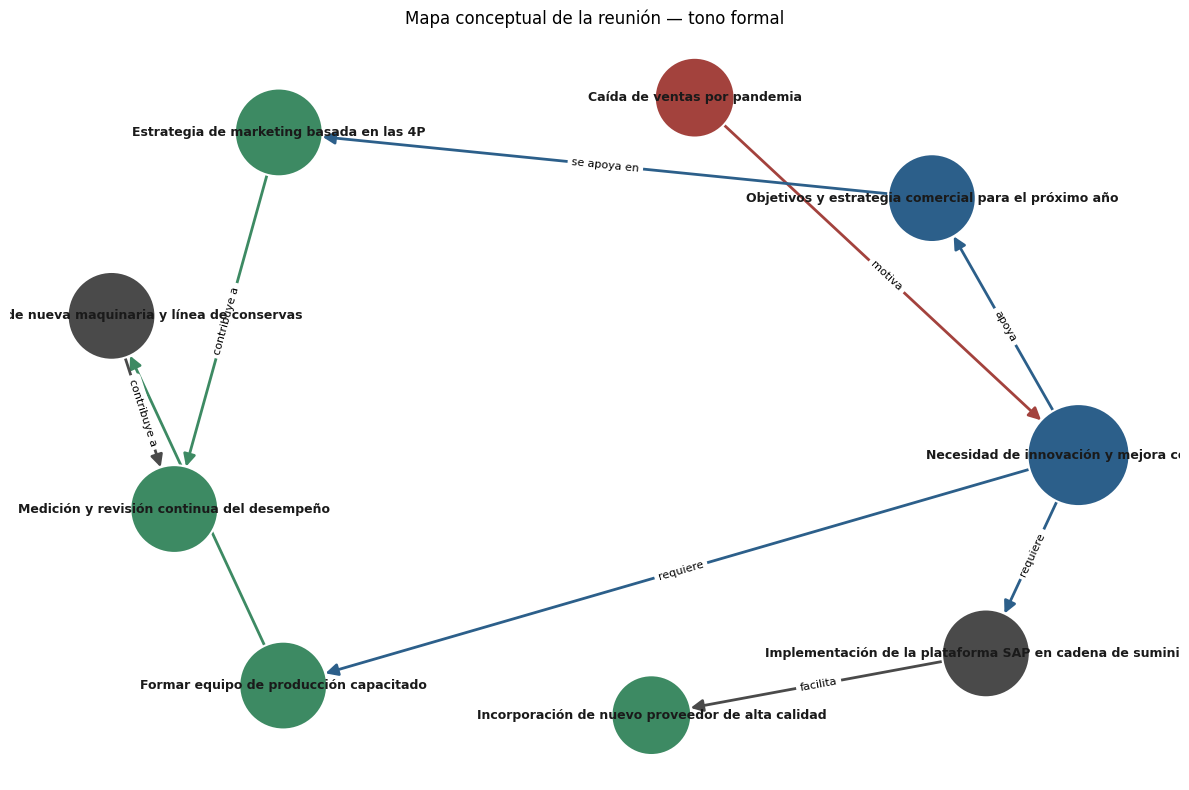

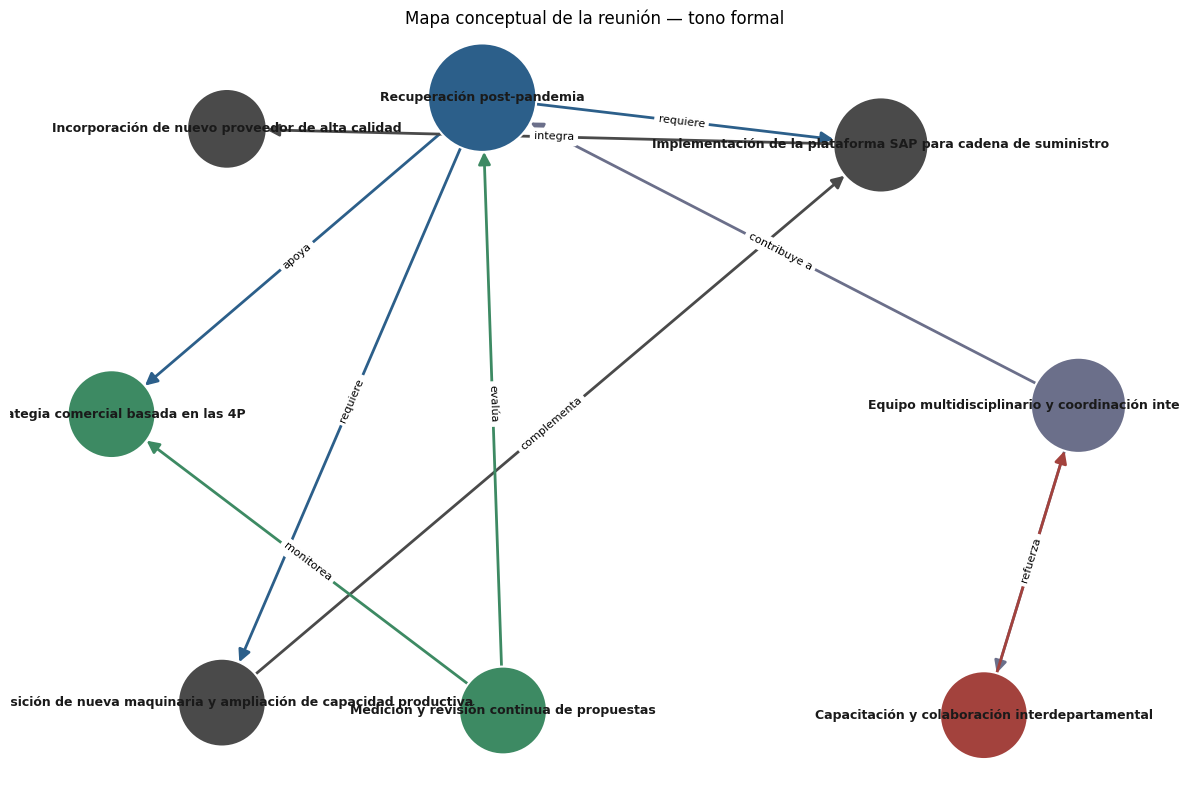


=== BLOQUE 3 FINALIZADO ===


In [4]:
os.makedirs("output", exist_ok=True)

# ===== Variante A: transcripcion.txt =====
with open(RUTA_TRANSCRIPCION, encoding="utf-8") as f:
    transcripcion_txt = f.read()

resumen_txt = generar_resumen(transcripcion_txt)

with open(RUTA_RESUMEN, "w", encoding="utf-8") as f:
    f.write(resumen_txt)


mapa_txt = graficar_mapa_conceptual(resumen_txt, RUTA_MAPA_CONCEPTUAL)

# ===== Variante B: transcripcion1.txt / transcripcion1.json =====
with open(RUTA_TRANSCRIPCION1, encoding="utf-8") as f:
    transcripcion1 = f.read()

resumen1 = generar_resumen(transcripcion1)

with open(RUTA_RESUMEN1, "w", encoding="utf-8") as f:
    f.write(resumen1)

mapa1 = graficar_mapa_conceptual(resumen1, RUTA_MAPA_CONCEPTUAL1)

print("\n=== BLOQUE 3 FINALIZADO ===")

## 4. Módulo RAG — Indexación y Consultas
Permite responder preguntas sobre lo charlado en la reunión (ej. *"¿qué
problemáticas se discutieron y con qué prioridad?"*) recuperando los fragmentos
relevantes de la transcripción.

## ¿Por qué se usan los embeddings de Cohere?

El módulo RAG no envía la transcripción completa al LLM: primero **busca** los fragmentos relevantes para la pregunta y solo esos se usan como contexto. Esa búsqueda se basa en **similitud de significado**, no en coincidencia de palabras, y para hacerla se necesita un modelo de embeddings.

- `CohereEmbeddings(model="embed-v4.0")` convierte cada fragmento de la reunión y cada pregunta en vectores numéricos. Los textos con significado parecido quedan cerca en el espacio vectorial.
- Se usa Cohere porque el LLM de Groq genera texto pero no es un modelo de embeddings, y `embed-v4.0` es multilingüe, apto para una reunión en español.
- El mismo objeto `embeddings` se usa para indexar los fragmentos en FAISS (`FAISS.from_documents`) y para vectorizar cada pregunta antes de buscar. Ambos deben usar el **mismo modelo** para que los vectores sean comparables.

## Funciones del módulo RAG: `crear_vectorstore`, `crear_vectorstore_texto` y `consultar_reunion`

### `crear_vectorstore(turnos)`
Indexa la reunión a partir de los **turnos de habla** del JSON:

1. Agrupa con `groupby` los turnos **consecutivos** de una misma persona en un solo bloque.
2. Cada bloque se convierte en un `Document` con el texto `Persona N: ...` y la metadata `hablante` y `minuto` (calculado desde el inicio del turno).
3. `FAISS.from_documents(docs, embeddings)` calcula los vectores y crea el índice de búsqueda.

Gracias a la metadata, el sistema puede responder **quién dijo qué y en qué momento**.

### `crear_vectorstore_texto(texto)`
Indexa la reunión a partir de la **transcripción en texto plano**, sin turnos ni tiempos:

1. Divide el texto en fragmentos de 1000 caracteres con 150 de solapamiento (`TAMANIO_CHUNK_RAG` y `SOLAPAMIENTO_CHUNK_RAG`).
2. Cada fragmento es un `Document` sin metadata.
3. Los indexa en FAISS igual que la función anterior.

Es la variante más simple. Como los cortes son por cantidad de caracteres, una intervención puede quedar partida entre dos fragmentos.

### `consultar_reunion(pregunta, vectorstore, k=4)`
Ejecuta el ciclo completo de RAG:

1. **Retrieval:** el *retriever* busca los `k=4` fragmentos más similares a la pregunta.
2. **Contexto:** los fragmentos se unen separados por `---`. Si tienen metadata, se antepone una etiqueta con el formato `[Persona 2 · minuto 5]`.
3. **Generación:** la cadena `prompt_rag | llm | StrOutputParser()` responde usando **solo** ese contexto. El prompt indica que, si se pide un listado, se ordene por criticidad y, si el contexto no alcanza, se indique.

In [5]:
from langchain_community.vectorstores import FAISS
from itertools import groupby
from langchain_core.documents import Document as LangChainDocument
from langchain_text_splitters import RecursiveCharacterTextSplitter

TAMANIO_CHUNK_RAG = 1000
SOLAPAMIENTO_CHUNK_RAG = 150

# Embeddings de Cohere para el RAG
embeddings = CohereEmbeddings(
    model="embed-v4.0"
)

INSTRUCCIONES_RAG = (
    "Respondé usando SOLO los fragmentos de la reunión que se muestran abajo como contexto. "
    "Los fragmentos son evidencia: NO los transcribas ni los cites textualmente. "
    "Analizalos y redactá una respuesta propia, sintetizada y directa, en prosa. "
    "Por ejemplo, si piden los participantes, respondé 'Las personas que participan son: "
    "Nombre1, Nombre2, Nombre3', sin repetir los diálogos donde aparecen. "
    "Si piden un listado de problemáticas, devolvelo ordenado por criticidad. "
    "Si el contexto no alcanza para responder, decilo. "
    "Solo citá una frase textual si el usuario lo pide explícitamente."
)

prompt_rag = ChatPromptTemplate.from_template(
    INSTRUCCIONES_RAG + "\n\nContexto:\n{contexto}\n\nPregunta: {pregunta}"
)


def crear_vectorstore(turnos: list[dict]):
    """
    Indexa la transcripción agrupada por turno de habla: cada documento es
    un bloque continuo de una persona, con metadata de hablante y minuto.
    Así el retrieval recupera QUIÉN dijo QUÉ y CUÁNDO.
    """
    docs = []
    for hablante, grupo in groupby(turnos, key=lambda t: t["hablante"]):
        grupo = list(grupo)
        minuto = int((grupo[0]["inicio"] or 0) // 60)
        docs.append(LangChainDocument(
            page_content=f"{hablante}: {' '.join(t['texto'] for t in grupo)}",
            metadata={"hablante": hablante, "minuto": minuto},
        ))
    return FAISS.from_documents(docs, embeddings)


def crear_vectorstore_texto(texto: str):
    """
    Indexa la transcripción en texto plano (sin turnos estructurados,
    sin metadata de hablante/minuto), partiéndola en fragmentos.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=TAMANIO_CHUNK_RAG, chunk_overlap=SOLAPAMIENTO_CHUNK_RAG
    )
    docs = [LangChainDocument(page_content=frag) for frag in splitter.split_text(texto)]
    return FAISS.from_documents(docs, embeddings)

def consultar_reunion(pregunta: str, vectorstore, k: int = 4) -> str:
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    fragmentos_relevantes = retriever.invoke(pregunta)

    partes_contexto = []
    for d in fragmentos_relevantes:
        if "hablante" in d.metadata:
            partes_contexto.append(f"[{d.metadata['hablante']} · minuto {d.metadata['minuto']}]\n{d.page_content}")
        else:
            partes_contexto.append(d.page_content)

    contexto = "\n\n---\n\n".join(partes_contexto)
    chain = prompt_rag | llm | StrOutputParser()
    return chain.invoke({"contexto": contexto, "pregunta": pregunta})               # 3. generation: el LLM responde SOLO con ese contexto


C:\Users\Admin\AppData\Local\Temp\ipykernel_3120\3323104368.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [6]:
os.makedirs("output", exist_ok=True)

PREGUNTA_PRUEBA = "¿Qué problemáticas se discutieron y con qué prioridad?"
PREGUNTA_PRUEBA_2 = "¿Qué personas tienen tareas asignadas?"

# ===== Variante A: transcripcion.txt (sin turnos, sin metadata) =====

with open(RUTA_TRANSCRIPCION, encoding="utf-8") as f:
    transcripcion_txt = f.read()

vectorstore_txt = crear_vectorstore_texto(transcripcion_txt)

respuesta_rag_txt = consultar_reunion(PREGUNTA_PRUEBA, vectorstore_txt)

with open(RUTA_RESPUESTA_RAG, "w", encoding="utf-8") as f:
    f.write(f"Pregunta: {PREGUNTA_PRUEBA}\n\n")
    f.write(f"Respuesta:\n{respuesta_rag_txt}")

consultar_reunion(PREGUNTA_PRUEBA_2, vectorstore_txt)

# ===== Variante B: transcripcion1.json (turnos con hablante/minuto) =====

with open(RUTA_TRANSCRIPCION_JSON, encoding="utf-8") as f:
    turnos1 = json.load(f)

vectorstore1 = crear_vectorstore(turnos1)

respuesta_rag1 = consultar_reunion(PREGUNTA_PRUEBA_2, vectorstore1)

with open(RUTA_RESPUESTA_RAG1, "w", encoding="utf-8") as f:
    f.write(f"Pregunta: {PREGUNTA_PRUEBA}\n\n")
    f.write(f"Respuesta:\n{respuesta_rag1}")

consultar_reunion(PREGUNTA_PRUEBA_2, vectorstore1)

print("\n=== BLOQUE 4 FINALIZADO ===")


=== BLOQUE 4 FINALIZADO ===


# GENERACION DE LA INTERFAZ

## Generación de la interfaz: componentes

La interfaz es un chat (Gradio) que permite hacer varias preguntas seguidas sobre la reunión.

### `prompt_condensar`
El *retriever* busca por la pregunta actual y no recuerda la conversación. Una pregunta de seguimiento como *"¿y quién lo dijo?"* no tiene sentido sola. Este prompt le pide al LLM que reescriba la última pregunta para que se entienda **sin el historial** (si ya es autocontenida, la devuelve igual). Esa versión reescrita se usa solo para buscar fragmentos.

### `prompt_chat`
Es el prompt de la respuesta final. Tiene tres partes:
- Un mensaje de sistema con las reglas (responder solo con el contexto, ordenar por criticidad los listados, avisar si no alcanza) y el `{contexto}` recuperado.
- `MessagesPlaceholder("historial")`, donde se insertan los mensajes previos de la conversación.
- La pregunta actual del usuario.

### `_a_mensajes(historial)`
Convierte el historial de Gradio (una lista de diccionarios con `role` y `content`) en objetos `HumanMessage` y `AIMessage` de LangChain. Solo toma los últimos `MAX_MENSAJES_HISTORIAL` (6) mensajes para no superar el límite de tokens de Groq, y maneja el caso en que Gradio envía el contenido en bloques en lugar de texto.

### `_armar_contexto(docs)`
Une los fragmentos recuperados en un solo texto para el prompt: antepone `[Persona · minuto]` cuando hay metadata y los separa con `---`. Repite la lógica de armado de contexto de `consultar_reunion`.

### `crear_chat(vectorstore, k=4)`
Es una función que **construye y devuelve** la función `responder(mensaje, historial)` que usará Gradio. Guarda el *retriever* y el parser dentro de esa función. Cada vez que el usuario escribe, `responder`:

1. Convierte el historial con `_a_mensajes`.
2. Si hay historial, reescribe la pregunta con `prompt_condensar`; si no, usa la pregunta tal cual.
3. Recupera fragmentos con la pregunta reescrita y arma el contexto con `_armar_contexto`.
4. Genera la respuesta con `prompt_chat`, usando el contexto, el historial y la pregunta original.

### `demo = gr.ChatInterface(...)`
Crea la interfaz web del chat. Sus parámetros: `fn=crear_chat(vectorstore1)` (función que responde; `vectorstore1` es la variante con hablante y minuto, y se puede usar `vectorstore_txt` para la variante de texto plano), `type="messages"` (historial como lista de diccionarios), `title`, `description` y `examples` (preguntas de ejemplo en un clic).

### `demo.launch()`
Inicia un servidor web local y muestra la interfaz en el notebook y en una URL local. Con `demo.launch(share=True)` se genera además un enlace público temporal para compartir.

In [7]:
import gradio as gr
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import MessagesPlaceholder

MAX_MENSAJES_HISTORIAL = 6   # últimos N mensajes (usuario+asistente); bajalo si Groq te da error de tokens

# Reescribe preguntas tipo "¿y quién lo dijo?" como preguntas autocontenidas para el retrieval
prompt_condensar = ChatPromptTemplate.from_template(
    "Dado el historial y la última pregunta del usuario, reescribí la última pregunta "
    "para que se entienda SIN el historial. Si ya es autocontenida, devolvela igual. "
    "Devolvé SOLO la pregunta.\n\nHistorial:\n{historial}\n\nÚltima pregunta: {pregunta}"
)

prompt_chat = ChatPromptTemplate.from_messages([
    ("system", INSTRUCCIONES_RAG + "\n\nContexto:\n{contexto}"),
    MessagesPlaceholder("historial"),
    ("human", "{pregunta}"),
])


def _a_mensajes(historial):
    msgs = []
    for m in historial[-MAX_MENSAJES_HISTORIAL:]:
        c = m["content"]
        if not isinstance(c, str):  # según versión, gradio puede mandar bloques
            c = "".join(b.get("text", "") for b in c if isinstance(b, dict))
        msgs.append(HumanMessage(c) if m["role"] == "user" else AIMessage(c))
    return msgs


def _armar_contexto(docs):
    partes = []
    for d in docs:
        if "hablante" in d.metadata:
            partes.append(f"[{d.metadata['hablante']} · minuto {d.metadata['minuto']}]\n{d.page_content}")
        else:
            partes.append(d.page_content)
    return "\n\n---\n\n".join(partes)


def crear_chat(vectorstore, k: int = 4):
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    parser = StrOutputParser()

    def responder(mensaje, historial):
        msgs = _a_mensajes(historial)

        if msgs:
            txt_hist = "\n".join(
                f"{'Usuario' if isinstance(m, HumanMessage) else 'Asistente'}: {m.content}"
                for m in msgs
            )
            consulta = (prompt_condensar | llm | parser).invoke(
                {"historial": txt_hist, "pregunta": mensaje}
            )
        else:
            consulta = mensaje

        contexto = _armar_contexto(retriever.invoke(consulta))
        return (prompt_chat | llm | parser).invoke(
            {"contexto": contexto, "historial": msgs, "pregunta": mensaje}
        )

    return responder

In [8]:
demo = gr.ChatInterface(
    fn=crear_chat(vectorstore1),   # vectorstore1 = con turnos/hablante; usá vectorstore_txt para la variante TXT
    type="messages",
    title="Asistente de la reunión",
    description="Preguntame lo que quieras sobre la reunión.",
    examples=[
        "¿Qué problemáticas se discutieron y con qué prioridad?",
        "¿Qué personas tienen tareas asignadas?",
    ],
)
demo.launch()   # demo.launch(share=True) para link público temporal

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 5. Módulo de Completado de Planilla (Norma ISO 9001)
A partir de la transcripción y el resumen, completa automáticamente la planilla
estandarizada de reunión (para que el responsable solo la revise y ajuste).

## ¿Por qué se crean las clases `Asistente`, `Acuerdo` y `PlanillaReunionISO9001`?

Son clases de **Pydantic** que describen, campo por campo, la información que necesita la Minuta de Reunión (ISO 9001). El LLM devuelve texto, pero para completar una plantilla Word hace falta información ordenada y tipada: la fecha en un campo, cada asistente en un ítem, cada acuerdo con su responsable y plazo. Estas clases son ese contrato.

| Clase | Representa | Campos |
|---|---|---|
| `Asistente` | Una fila de la tabla de asistentes | `puesto`, `nombre`, `asistio` (bool) y `motivo_ausencia` |
| `Acuerdo` | Una fila de la tabla de acuerdos | `responsable`, `actividad` y `plazo` |
| `PlanillaReunionISO9001` | La minuta completa | `fecha`, `hora_inicio`, `hora_fin`, `lugar`, `objetivo`, `asistentes` (lista de `Asistente`), `orden_del_dia` (lista de temas), `acuerdos` (lista de `Acuerdo`), `resumen_final` y `duracion_min` |

Se separan en tres clases porque la minuta tiene una estructura anidada: una planilla contiene **varios** asistentes y **varios** acuerdos, y cada uno tiene sus propios campos.

**Detalles de diseño:**

- Cada `Field(description=...)` le explica al LLM qué debe poner en ese campo (por ejemplo, formato `dd/mm/aaaa` para la fecha o `HH:MM` para las horas).
- Los límites (máximo 12 temas en `orden_del_dia` y 6 en `acuerdos`) coinciden con la cantidad de filas disponibles en la plantilla Word.
- `resumen_final` y `duracion_min` no tienen descripción porque el código los completa después (con el resumen generado y con los tiempos reales de la transcripción, cuando están disponibles).
- Al usarse con `with_structured_output`, el LLM está obligado a responder con esta estructura y Pydantic la valida.

## ¿Cómo funciona `completar_planilla()`? ¿Cómo usa el `chain`?

La función recibe la transcripción y el resumen de la reunión, y devuelve un objeto `PlanillaReunionISO9001` con todos los datos de la minuta.

Su núcleo es una sola cadena (*chain*):

`chain = prompt_planilla | llm.with_structured_output(PlanillaReunionISO9001)`

**Cómo se arma:**

1. **`prompt_planilla`:** plantilla con dos variables, `{resumen}` y `{transcripcion}`. Le indica al LLM que:
   - Deduzca los puestos según el contexto (un puesto por persona; quien no tenga puesto es invitado).
   - Marque quién asistió (nombre y apellido) y quién no.
   - Complete el encabezado (fecha, horas, lugar, objetivo), los temas tratados y los acuerdos con responsable y plazo.
2. **`llm.with_structured_output(PlanillaReunionISO9001)`:** envuelve al LLM para que su respuesta se ajuste al esquema de la clase y se devuelva ya convertida en un objeto Python validado.
3. **`chain.invoke({...})`:** ejecuta la cadena con el resumen y la transcripción.

A diferencia de las cadenas del resumen, esta **no usa `StrOutputParser`**: con salida estructurada el resultado no es un texto sino un objeto, y la conversión la hace `with_structured_output`.

Se le pasan tanto el resumen como la transcripción: el resumen da la visión general y la transcripción aporta los detalles (nombres, plazos, horarios).

## ¿Qué función tiene `exportar_planilla()`?

Toma los datos de la planilla y los vuelca en la plantilla Word real de la fábrica ("Minuta de Reunión.docx") para generar el documento final, que el responsable solo tiene que revisar. Usa la librería `python-docx`.

**Pasos:**

1. **Abre la plantilla** y toma sus cuatro primeras tablas: encabezado, asistentes, orden del día y acuerdos.
2. **Encabezado:** escribe fecha, hora de inicio, lugar, hora de fin y objetivo en sus celdas.
3. **Asistentes:**
   - Recorre las filas de la plantilla y, si el puesto de la fila coincide con el de un asistente, escribe su nombre (o `Ausente (motivo)` si no asistió y hay un motivo).
   - Los asistentes que no coincidían con ningún puesto de la plantilla se ubican en las filas vacías disponibles.
   - Si no alcanzan las filas, agrega filas nuevas a la tabla.
4. **Orden del día:** escribe los temas en las filas 1 a 12.
5. **Acuerdos:** escribe responsable, actividad y plazo en las filas destinadas a acuerdos (hasta 6).
6. **Cierre del documento:** agrega la fecha actual a la línea "Temas tratados", añade el título "Resumen final:" y debajo, el resumen línea por línea.
7. **Guarda** el resultado en `ruta_salida`.

Así se conserva el formato original de la fábrica en lugar de crear un documento nuevo desde cero.

## Variantes A y B: `transcripcion.txt` vs `transcripcion1.txt` / `transcripcion1.json`

El notebook procesa la reunión de dos maneras, para **comparar el resultado** de una transcripción básica contra una mejorada. Cada variante parte de una versión distinta de la función `transcribir_audio`.

| Aspecto | Variante A | Variante B |
|---|---|---|
| Archivos | `transcripcion.txt` | `transcripcion1.txt` y `transcripcion1.json` |
| Modelo Whisper | `small` | `large-v3` (mayor calidad) |
| Idioma | Detectado automáticamente | Fijado en español |
| Hablantes | Detectados libremente | Se fija la cantidad (`num_hablantes=5`) |
| Diagnóstico de audio | No | Sí (duración, palabras por minuto, etc.) |
| Datos de la transcripción | Solo texto `Persona N: ...` | Texto, más turnos con `hablante`, `inicio` y `fin` |
| Indexación RAG | `crear_vectorstore_texto` (fragmentos de 1000 caracteres, sin metadata) | `crear_vectorstore` (turnos completos con hablante y minuto) |
| Duración de la reunión | La estima el LLM | Se calcula exacta con los tiempos del JSON |
| Archivos de salida | `resumen_reunion.txt`, `mapa_conceptual_reunion.png`, `respuesta_rag.txt`, `planilla_reunion.docx` | Los mismos con sufijo `1` |

**Diferencia principal:** la variante B conserva información estructurada (quién habló y cuándo), lo que mejora el RAG (responde "quién dijo qué") y permite calcular la duración real. La variante A es más simple pero pierde ese detalle.

**Nota sobre la variante B en el módulo 5:** en el bloque 5 se llama `completar_planilla(resumen1, resumen1)`, es decir, se envía el resumen en lugar de la transcripción completa. Con `large-v3` la transcripción es más extensa y, sumada al prompt y al resumen, supera el límite de tokens de Groq.

In [9]:
from pydantic import BaseModel, Field
from typing import List


class Asistente(BaseModel):
    puesto: str = Field(description=f"El puesto puesto de cada uno de los participantes, podrías deducirlo en base a la transcripción y al resumen de la reunión")
    nombre: str = Field(description="Nombre y apellido de quien ocupa ese puesto; string vacío si no asistió")
    asistio: bool = Field(description="True si participó de la reunión según la transcripción")
    motivo_ausencia: str = Field(description="Motivo de la ausencia si se menciona en la transcripción; vacío si no aplica o no se sabe")


class Acuerdo(BaseModel):
    responsable: str = Field(description="Responsable de la tarea/acuerdo")
    actividad: str = Field(description="Actividad/tarea/acción acordada")
    plazo: str = Field(description="Plazo o fecha de ejecución acordada")


class PlanillaReunionISO9001(BaseModel):
    """Minuta de Reunión — planilla estandarizada de la fábrica (ISO 9001)."""
    fecha: str = Field(description="Fecha de la reunión, formato dd/mm/aaaa")
    hora_inicio: str = Field(description="Hora de inicio, formato HH:MM")
    hora_fin: str = Field(description="Hora de fin, formato HH:MM")
    lugar: str = Field(description="Lugar de la reunión")
    objetivo: str = Field(description="Objetivo/motivo de la reunión, en 1-2 oraciones")
    asistentes: List[Asistente] = Field(description=f"Un ítem por cada puesto deducido por asistente, más invitados externos que hayan participado")
    orden_del_dia: List[str] = Field(description="Temas tratados, en el orden en que se charlaron (máx. 12)")
    acuerdos: List[Acuerdo] = Field(description="Acuerdos/tareas con responsable y plazo (máx. 6)")
    resumen_final: str
    duracion_min: float

In [10]:
from docx import Document
from datetime import date
from docx import Document as WordDocument

prompt_planilla = ChatPromptTemplate.from_template(
    "Sos un asistente que completa la Minuta de Reunión de una fábrica "
    "(formato ISO 9001) a partir de la transcripción y el resumen de una "
    "reunión de trabajo.\n\n"
    "Los puestos deben completarse según el contexto de la reunión (obviamente, un puesto por persona, ni más, ni menos. Si una persona" \
    "no tiene puesto es porque es invitado), podes deducirlos. Para "
    "cada uno de esos puestos, indicá si participó y quién (nombre y "
    "apellido) según la transcripción; si no hay evidencia de que haya "
    "participado, marcalo como no asistió. Si aparecen invitados externos "
    "no listados, agregalos también.\n\n"
    "Además, completá el encabezado con la fecha, hora de inicio y fin, lugar, objetivo de la reunión, los temas tratados (orden del día) "
    "y los acuerdos/tareas con responsable y plazo, según la transcripción y el resumen.\n\n"
    "Al final, debajo de 'Temas tratados:', se debe completar con la fecha actual y colocar un resumen de la reunión en español, en viñetas, "
    "con los temas tratados y las conclusiones/acuerdos principales.\n\n"
    "Resumen:\n{resumen}\n\nTranscripción completa:\n{transcripcion}"
)


def completar_planilla(transcripcion: str, resumen: str) -> PlanillaReunionISO9001:
    """
    Completa la planilla de reunión (Minuta ISO 9001) con salida
    estructurada del LLM sobre PlanillaReunionISO9001.
    """
    chain = prompt_planilla | llm.with_structured_output(PlanillaReunionISO9001)
    return chain.invoke({"resumen": resumen, "transcripcion": transcripcion})

def exportar_planilla(planilla: PlanillaReunionISO9001, ruta_plantilla: str, ruta_salida: str):
    """
    Completa la plantilla Word "Minuta de Reunión" (la que usa la fábrica)
    con los datos de `planilla` y guarda el resultado en `ruta_salida`,
    para que el responsable de la reunión solo la revise y firme.
    """
    doc = WordDocument(ruta_plantilla)
    tabla_encabezado, tabla_asistentes, tabla_orden_dia, tabla_acuerdos = doc.tables[:4]

    # --- Encabezado: fecha, horario, lugar, objetivo -----------------------
    tabla_encabezado.rows[0].cells[1].text = planilla.fecha
    tabla_encabezado.rows[0].cells[3].text = planilla.hora_inicio
    tabla_encabezado.rows[1].cells[1].text = planilla.lugar
    tabla_encabezado.rows[1].cells[3].text = planilla.hora_fin
    tabla_encabezado.rows[3].cells[0].text = planilla.objetivo

    # --- Asistentes ---
    asistentes_por_puesto = {a.puesto: a for a in planilla.asistentes}

    filas_libres = []

    for fila in tabla_asistentes.rows[2:]:
        puesto = fila.cells[1].text.strip()
        asistente = asistentes_por_puesto.pop(puesto, None) if puesto else None

        if asistente:
            if asistente.asistio:
                fila.cells[0].text = asistente.nombre
            elif asistente.motivo_ausencia:
                fila.cells[0].text = f"Ausente ({asistente.motivo_ausencia})"
        elif not puesto and not fila.cells[0].text.strip():
            # fila vacía en la plantilla -> disponible para el resto
            filas_libres.append(fila)

    restantes = list(asistentes_por_puesto.values())

    for fila, asistente in zip(filas_libres, restantes):
        fila.cells[0].text = asistente.nombre
        fila.cells[1].text = asistente.puesto

    # si sobran asistentes y no alcanzan las filas vacías, se agregan filas nuevas
    for asistente in restantes[len(filas_libres):]:
        fila = tabla_asistentes.add_row()
        fila.cells[0].text = asistente.nombre
        fila.cells[1].text = asistente.puesto

    # --- Orden del día (hasta 12 temas) -------------------------------------
    for fila, tema in zip(tabla_orden_dia.rows[1:13], planilla.orden_del_dia):
        fila.cells[1].text = tema

    # --- Acuerdos (hasta 6) ---------------------------------------------
    for fila, acuerdo in zip(tabla_acuerdos.rows[2:8], planilla.acuerdos):
        fila.cells[0].text = acuerdo.responsable
        fila.cells[1].text = acuerdo.actividad
        fila.cells[2].text = acuerdo.plazo

    # --- Resumen final al final del documento ---
    fecha_hoy = date.today().strftime("%d/%m/%Y")

    for parrafo in doc.paragraphs:
        if "Temas tratados" in parrafo.text:
            parrafo.add_run(f"  {fecha_hoy}")
            break

    doc.add_paragraph("Resumen final:")

    for linea in planilla.resumen_final.split("\n"):
        linea = linea.strip()
        if linea:
            doc.add_paragraph(linea)

    doc.save(ruta_salida)

In [11]:
os.makedirs("output", exist_ok=True)

# ===== Variante A: transcripcion.txt =====
with open(RUTA_TRANSCRIPCION, encoding="utf-8") as f:
    transcripcion_txt = f.read()

if "resumen_txt" not in globals():
    print("[TXT] No se encontró el resumen. Generándolo...")
    resumen_txt = generar_resumen(transcripcion_txt)


planilla_txt = completar_planilla(transcripcion_txt, resumen_txt)
planilla_txt.resumen_final = resumen_txt
# Sin turnos con timestamps en esta variante: se conserva la duración que el propio LLM estimó en completar_planilla.

planilla_txt.model_dump_json(indent=2, ensure_ascii=False)

exportar_planilla(planilla_txt, RUTA_PLANTILLA_MINUTA, RUTA_PLANILLA_SALIDA)

# ===== Variante B: transcripcion1.txt / transcripcion1.json =====
with open(RUTA_TRANSCRIPCION1, encoding="utf-8") as f:
    transcripcion1 = f.read()

with open(RUTA_TRANSCRIPCION_JSON, encoding="utf-8") as f:
    turnos1 = json.load(f)

if "resumen1" not in globals():
    print("\n[1] No se encontró el resumen. Generándolo...")
    resumen1 = generar_resumen(transcripcion1)

print("\n[1] Generando información estructurada de la reunión...")

# No le mando la trnscripción completa porque al ser generada por un modelo más grande, la misma es más grande y, mas el prompt y el resumen, se pasa del límite de 8000 tokens del modelo.
planilla1 = completar_planilla(resumen1, resumen1)                      
planilla1.resumen_final = resumen1
planilla1.duracion_min = (turnos1[-1]["fin"] - turnos1[0]["inicio"]) / 60

print("[1] Datos de la planilla generados correctamente.")
print("\n=== DATOS DE LA PLANILLA [1] ===\n")
print(planilla1.model_dump_json(indent=2, ensure_ascii=False))

exportar_planilla(planilla1, RUTA_PLANTILLA_MINUTA, RUTA_PLANILLA_SALIDA1)
print(f"\n[1] Planilla completada: {RUTA_PLANILLA_SALIDA1}")

print("\n=== BLOQUE 5 FINALIZADO ===")


[1] Generando información estructurada de la reunión...


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-120b` in organization `org_01m2r2yk0pefat4ek3da01qpdv` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Used 5460, Requested 3634. Please try again in 8.205s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

## 6. Orquestación — Agente principal (Langchain)
Combina los módulos anteriores como *tools* de un agente, o como un pipeline
secuencial simple (a definir cuál conviene según lo visto en clase).

## ¿Qué hace la orquestación?

La **orquestación** conecta los módulos anteriores (transcripción, resumen, RAG y planilla) para usarlos como un solo sistema. El bloque tiene dos partes.

### 1. Pipeline `procesar_reunion(...)`
Es un proceso **determinístico** que se ejecuta una sola vez por reunión. Recibe la transcripción (y opcionalmente los turnos) y:

1. Genera el resumen con `generar_resumen`.
2. Genera el mapa conceptual con `graficar_mapa_conceptual`.
3. Crea el índice RAG: con `crear_vectorstore` si hay turnos, o con `crear_vectorstore_texto` si solo hay texto.
4. Guarda los resultados en **variables globales** (`transcripcion_actual`, `resumen_actual`, `vectorstore_actual`, `ruta_planilla_actual`).

Se usan variables globales porque las *tools* solo reciben los parámetros que el LLM decide pasar (por ejemplo, la pregunta). El resto del estado (resumen, índice, rutas) tiene que estar disponible en algún lugar.

### 2. Tools del agente
Con el decorador `@tool` de LangChain se convierten dos funciones en herramientas que un agente puede elegir:

| Tool | Cuándo la usaría el agente | Qué hace |
|---|---|---|
| `ConsultarReunion(pregunta)` | Cuando el usuario pregunta sobre lo hablado | Llama a `consultar_reunion` sobre el índice RAG actual |
| `CompletarPlanilla()` | Cuando el usuario pide la minuta | Llama a `completar_planilla`, exporta el Word y devuelve la ruta |

La docstring de cada tool es lo que el LLM lee para decidir cuál usar. Ambas comprueban que la reunión ya haya sido procesada y, si no, devuelven un aviso.

**Idea general:** el pipeline hace el trabajo pesado una vez, y el agente decide, según lo que pida el usuario, qué herramienta usar.

In [ ]:
from langchain.agents import create_agent
from langchain.tools import tool

transcripcion_actual = None
resumen_actual = None
vectorstore_actual = None
ruta_planilla_actual = RUTA_PLANILLA_SALIDA


def procesar_reunion(transcripcion: str, turnos: list[dict] | None = None,
                      ruta_mapa: str = RUTA_MAPA_CONCEPTUAL,
                      ruta_planilla: str = RUTA_PLANILLA_SALIDA):
    """
    Pipeline determinístico que corre una vez por reunión: genera el
    resumen, el mapa conceptual y el índice para RAG (módulos 3 y 4), y
    deja todo en variables globales para que las tools del agente lo usen.
    Si se pasan `turnos` (transcripcion1.json), indexa con metadata de
    hablante/minuto; si no, indexa el texto plano (transcripcion.txt).
    """
    global transcripcion_actual, resumen_actual, vectorstore_actual, ruta_planilla_actual
    transcripcion_actual = transcripcion
    resumen_actual = generar_resumen(transcripcion)
    graficar_mapa_conceptual(resumen_actual, ruta_mapa)
    vectorstore_actual = crear_vectorstore(turnos) if turnos is not None else crear_vectorstore_texto(transcripcion)
    ruta_planilla_actual = ruta_planilla


@tool
def ConsultarReunion(pregunta: str) -> str:
    """Responde preguntas sobre lo charlado en la reunión (temas, prioridades, acuerdos), en base a lo indexado con RAG."""
    if vectorstore_actual is None:
        return "Todavía no se procesó ninguna reunión (correr procesar_reunion primero)."
    return consultar_reunion(pregunta, vectorstore_actual)


@tool
def CompletarPlanilla() -> str:
    """Completa la Minuta de Reunión (ISO 9001) de la reunión ya procesada y la guarda en la ruta activa."""
    if resumen_actual is None or transcripcion_actual is None:
        return "Todavía no se procesó ninguna reunión (correr procesar_reunion primero)."
    planilla = completar_planilla(transcripcion_actual, resumen_actual)                         # Evaliuar pasar la transcripcion
    exportar_planilla(planilla, RUTA_PLANTILLA_MINUTA, ruta_planilla_actual)
    return f"Planilla completada y guardada en {ruta_planilla_actual}"

In [ ]:
SYSTEM_PROMPT = (
    "Sos un asistente de gestión de reuniones. "
    "Usá la herramienta ConsultarReunion para responder preguntas sobre lo que se habló "
    "(temas, prioridades, quién dijo qué). "
    "Usá la herramienta CompletarPlanilla cuando pidan completar la minuta o planilla ISO 9001. "
    "Si la pregunta no requiere ninguna herramienta, respondé directamente."
)

agente = create_agent(
    llm,
    tools=[ConsultarReunion, CompletarPlanilla],
    system_prompt=SYSTEM_PROMPT,
)

In [ ]:
# Cargar el estado de la reunión SIN volver a llamar al LLM
# (requiere haber corrido antes los bloques 3 y 4 de la variante B)
transcripcion_actual = transcripcion1
resumen_actual = resumen1
vectorstore_actual = vectorstore1
ruta_planilla_actual = RUTA_PLANILLA_SALIDA1


def mostrar_uso_de_tools(pedido: str):
    resultado = agente.invoke({"messages": [{"role": "user", "content": pedido}]})
    print(f"👤 Usuario: {pedido}\n")
    for m in resultado["messages"]:
        if m.type == "ai" and m.tool_calls:
            for tc in m.tool_calls:
                print(f"🔧 El agente eligió la tool: {tc['name']} | argumentos: {tc['args']}")
        elif m.type == "tool":
            print(f"📥 Resultado de {m.name}: {str(m.content)[:300]}...\n")
        elif m.type == "ai":
            print(f"🤖 Respuesta final: {m.content}")
    print("-" * 60)


mostrar_uso_de_tools("¿Qué problemáticas se discutieron y con qué prioridad?")   
mostrar_uso_de_tools("Completá la planilla de esta reunión")                     
mostrar_uso_de_tools("Hola, ¿qué podés hacer?")                                  

👤 Usuario: ¿Qué problemáticas se discutieron y con qué prioridad?

🔧 El agente eligió la tool: ConsultarReunion | argumentos: {'pregunta': '¿Qué problemáticas se discutieron y con qué prioridad?'}
📥 Resultado de ConsultarReunion: **Problemáticas discutidas (ordenadas por criticidad)**  

1. **Disminución de ventas provocada por la pandemia**  
   - *Fragmento:* “...el tema de la pandemia nos ha afectado un poco, nuestras ventas han disminuido...” (Persona 4, minuto 7).  

2. **Necesidad de adquirir equipos tecnológicos para ...

🤖 Respuesta final: **Problemáticas discutidas (ordenadas por prioridad)**  

1. **Disminución de ventas provocada por la pandemia**  
   - *Prioridad alta* – Impacta directamente los ingresos y la sostenibilidad del negocio.  

2. **Necesidad de adquirir equipos tecnológicos para mejorar la producción**  
   - *Prioridad alta* – Es clave para aumentar la capacidad y eficiencia productiva.  

3. **Problemas de almacenamiento de materias primas**  
   - *Priorida

## 7. Casos de prueba

Es la **prueba de punta a punta** del sistema: ejecuta todos los módulos en orden, con la misma reunión, para comprobar que funcionan en conjunto y dejar evidencia para la defensa oral. Se corre una vez por variante (A y B) con la pregunta de prueba *"¿qué problemáticas se discutieron y con qué prioridad?"*.

**Secuencia para cada variante:**

| Módulo | Qué prueba |
|---|---|
| Módulo 3 | Genera e imprime el resumen y grafica el mapa conceptual |
| Módulo 4 | Crea el índice RAG y responde la pregunta de prueba |
| Módulo 5 | Completa la planilla, muestra sus datos y exporta el Word |
| Módulo 6 | Ejecuta `procesar_reunion` y luego consulta al agente: primero la pregunta sobre la reunión y después *"Completá la planilla de esta reunión"* |

Como se ejecuta con ambas variantes, sirve además para **comparar** los resultados de la transcripción básica (A) con los de la mejorada (B).

**Advertencia del propio código:** el módulo 6 repite llamadas al LLM ya realizadas en los módulos 3 a 5, lo que consume más cuota de API. Este bloque es una verificación final, no parte del flujo normal de uso.

Elen Contreras, Gerente General, abrió la reunión contextualizando la situación actual de Pesquera Diamante, empresa con flota propia dedicada al procesamiento de harina, aceite, conservas y productos congelados. Señaló que la pandemia modificó significativamente el entorno de negocio y que la compañía se encuentra en una fase de transformación que exige a sus ejecutivos la capacidad de adaptarse a los cambios, impulsar la innovación, la digitalización y la optimización de procesos para recuperar y ampliar su competitividad.

En el área de producción, Ezequiel Pinedo expuso la necesidad de constituir un equipo altamente capacitado que incluya operarios, analistas y visitadores, en estrecha coordinación con Recursos Humanos y el almacén. Se planteó la adquisición de nueva maquinaria para iniciar una línea de conservas y, paralelamente, ampliar la capacidad de los almacenes con el fin de recibir mayores volúmenes de materias primas. Estas inversiones buscan mejorar la eficiencia operativ

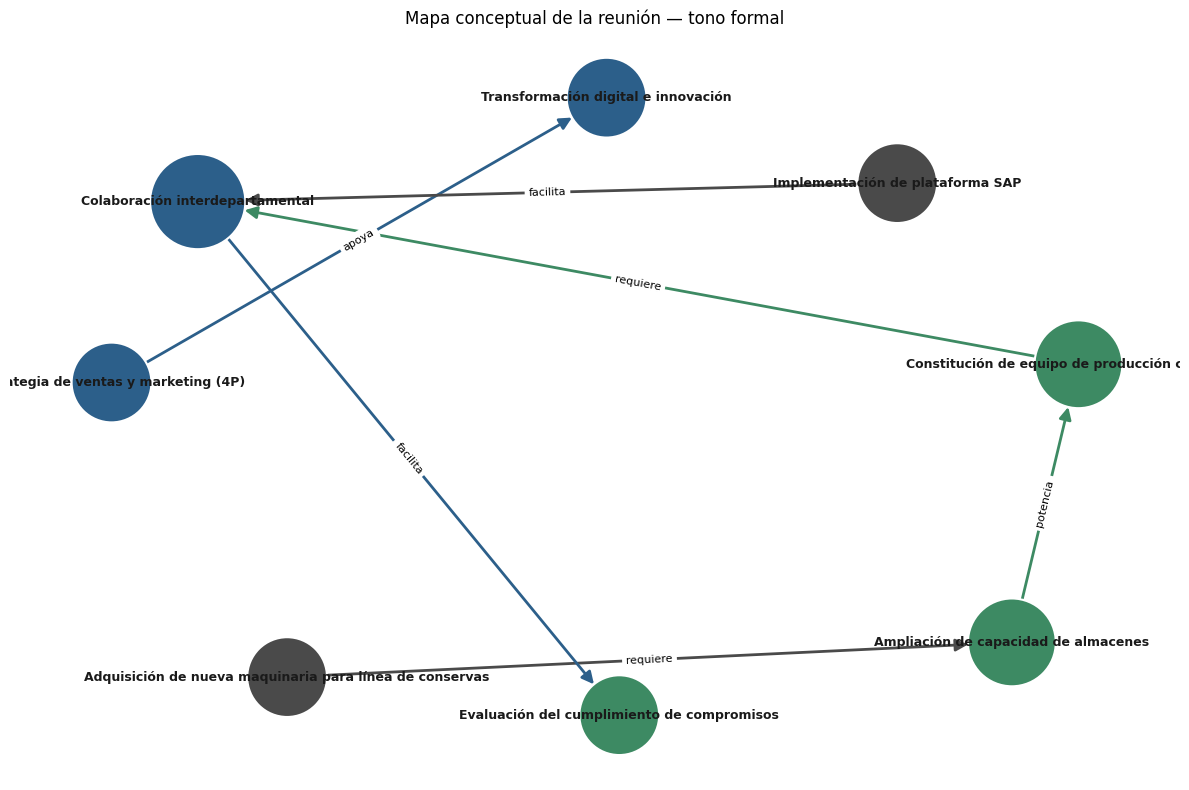

**Problemáticas discutidas (ordenadas por criticidad)**  

1. **Disminución de ventas por la pandemia**  
   - *“nuestras ventas son disminuidos, pero por otro lado, nosotros también sabemos que brindamos productos de alta gama de buena calidad de nutrición.”*  

2. **Necesidad de un nuevo proveedor con altos estándares y entregas más rápidas**  
   - *“para el inicio del 2023 está considerando una una propuesta que vamos a con un nuevo proveedor”*  
   - *“Debo trabajar con un nuevo proveedor que también está trabajando con altos estándares de calidad, la cual eso también lo va a ayudar muchísimo a la empresa para que todos sus producciones, sus pedidos sean de manera correcta entregada hace menos tiempo.”*  

3. **Adquisición de equipos tecnológicos para mejorar la producción**  
   - *“estamos a puertas de poder adquirir los equipos, esos equipos tecnológicos para poder mejorar nuestra producción.”*  

4. **Mejorar el almacenamiento de materias primas**  
   - *“Y también el tema de

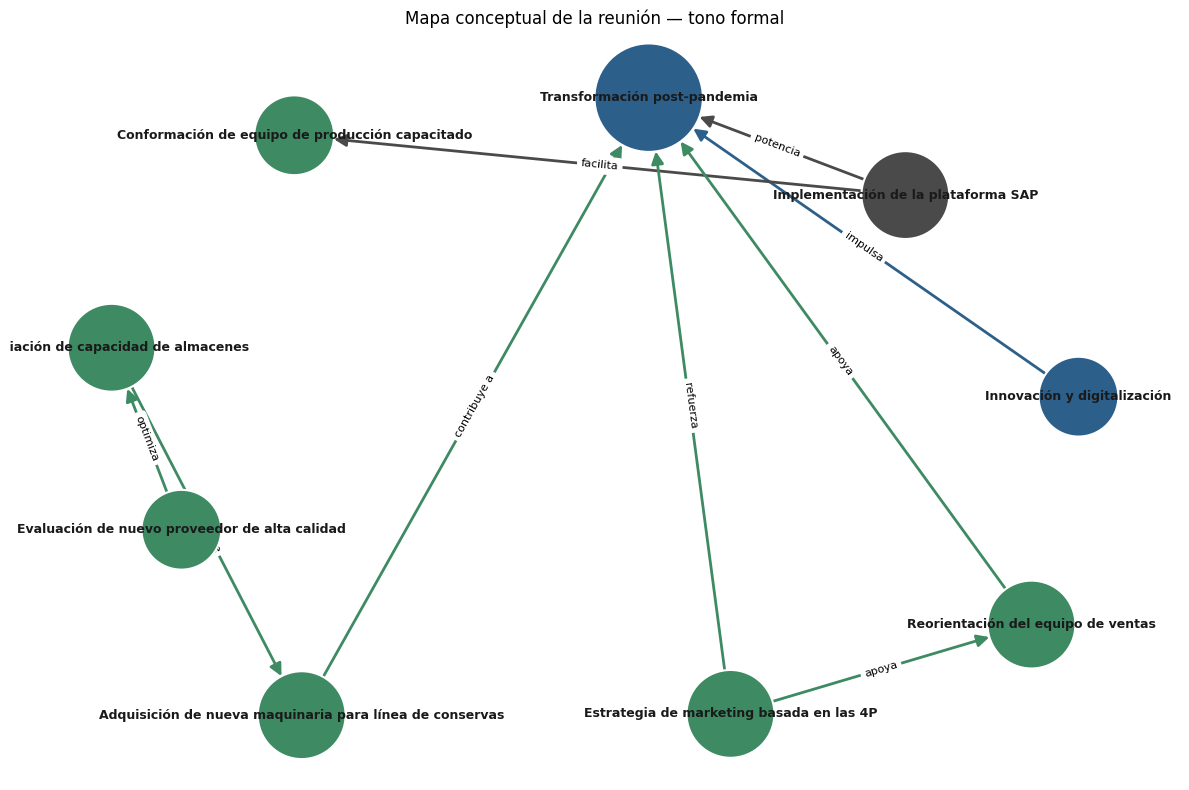

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-120b` in organization `org_01m2r5m1f4exm9qf15cn3vfqdf` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 198559, Requested 2727. Please try again in 9m15.552s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

Traceback (most recent call last):
  File "c:\Users\Admin\Desktop\Estudios\Sistemas-2026\IA\TPN2\venv\lib\site-packages\gradio\queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
  File "c:\Users\Admin\Desktop\Estudios\Sistemas-2026\IA\TPN2\venv\lib\site-packages\gradio\route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
  File "c:\Users\Admin\Desktop\Estudios\Sistemas-2026\IA\TPN2\venv\lib\site-packages\gradio\blocks.py", line 2191, in process_api
    result = await self.call_function(
  File "c:\Users\Admin\Desktop\Estudios\Sistemas-2026\IA\TPN2\venv\lib\site-packages\gradio\blocks.py", line 1696, in call_function
    prediction = await fn(*processed_input)
  File "c:\Users\Admin\Desktop\Estudios\Sistemas-2026\IA\TPN2\venv\lib\site-packages\gradio\utils.py", line 882, in async_wrapper
    response = await f(*args, **kwargs)
  File "c:\Users\Admin\Desktop\Estudios\Sistemas-2026\IA\TPN2\venv\lib\site-p

In [ ]:
from langchain_core.documents import Document as LangChainDocument

PREGUNTA_CASO = "¿qué problemáticas se discutieron y con qué prioridad?"

# ========================= VARIANTE A: transcripcion.txt =========================
with open(RUTA_TRANSCRIPCION, encoding="utf-8") as f:
    transcripcion_txt = f.read()

# --- Módulo 3 ---
resumen_txt = generar_resumen(transcripcion_txt)
print(resumen_txt)
mapa_txt = graficar_mapa_conceptual(resumen_txt, RUTA_MAPA_CONCEPTUAL)

# --- Módulo 4 ---
vectorstore_txt = crear_vectorstore_texto(transcripcion_txt)
print(consultar_reunion(PREGUNTA_CASO, vectorstore_txt))

# --- Módulo 5 ---
planilla_txt = completar_planilla(vectorstore_txt, resumen_txt)
print(planilla_txt.model_dump())
exportar_planilla(planilla_txt, RUTA_PLANTILLA_MINUTA, RUTA_PLANILLA_SALIDA)

# --- Módulo 6 ---
procesar_reunion(transcripcion_txt, ruta_mapa=RUTA_MAPA_CONCEPTUAL, ruta_planilla=RUTA_PLANILLA_SALIDA)

respuesta_txt = agente.invoke({"messages": [
    {"role": "user", "content": PREGUNTA_CASO}
]})
print(respuesta_txt["messages"][-1].content)

respuesta_planilla_txt = agente.invoke({"messages": [
    {"role": "user", "content": "Completá la planilla de esta reunión"}
]})
print(respuesta_planilla_txt["messages"][-1].content)

# ==================== VARIANTE B: transcripcion1.txt / .json =====================
# =================================================================================
with open(RUTA_TRANSCRIPCION1, encoding="utf-8") as f:
    transcripcion1 = f.read()

with open(RUTA_TRANSCRIPCION_JSON, encoding="utf-8") as f:
    turnos1 = json.load(f)

# --- Módulo 3 ---
resumen1 = generar_resumen(transcripcion1)
print(resumen1)
mapa1 = graficar_mapa_conceptual(resumen1, RUTA_MAPA_CONCEPTUAL1)

# --- Módulo 4 ---
vectorstore1 = crear_vectorstore(turnos1)
print(consultar_reunion(PREGUNTA_CASO, vectorstore1))

# --- Módulo 5 ---
planilla1 = completar_planilla(vectorstore1, resumen1)
planilla1.duracion_min = (turnos1[-1]["fin"] - turnos1[0]["inicio"]) / 60
print(planilla1.model_dump())
exportar_planilla(planilla1, RUTA_PLANTILLA_MINUTA, RUTA_PLANILLA_SALIDA1)

# --- Módulo 6 ---
# NOTA: repite llamadas al LLM ya hechas arriba (gasta más cuota de API).
procesar_reunion(transcripcion1, turnos=turnos1, ruta_mapa=RUTA_MAPA_CONCEPTUAL1, ruta_planilla=RUTA_PLANILLA_SALIDA1)

respuesta1 = agente.invoke({"messages": [
    {"role": "user", "content": PREGUNTA_CASO}
]})
print(respuesta1["messages"][-1].content)

respuesta_planilla1 = agente.invoke({"messages": [
    {"role": "user", "content": "Completá la planilla de esta reunión"}
]})
print(respuesta_planilla1["messages"][-1].content)

## 8. Conclusiones y dificultades

## Conclusiones

**Transcripción.** Las transcripciones generadas con ambas configuraciones de WhisperX (variante A con `small` y variante B con `large-v3`) resultaron prácticamente iguales. La ventaja de la variante B es que, además del texto, produce un archivo `.json` con los metadatos estructurados de cada turno (hablante, inicio y fin). Esos metadatos enriquecen las etapas posteriores (RAG, resúmenes y planilla) y permiten, por ejemplo, calcular cuánto tiempo se desarrolló una idea, cuánto habló cada participante y en qué momento se trató cada tema.

**Resumen y mapa conceptual.** Los resúmenes obtenidos a partir de ambas transcripciones son muy similares y, por lo tanto, los mapas conceptuales generados a partir de ellos también lo son.

**RAG.** Las respuestas fueron mejores cuando el `vectorstore` se generó a partir de la transcripción completa en texto plano (variante A) que cuando se creó a partir del `.json` con los turnos de habla (variante B).

**Planilla ISO 9001.** Lo ideal para completar la planilla es entregarle al modelo la transcripción completa. En nuestro caso no fue posible: la transcripción consumía alrededor de 4.500 tokens, y el plan gratuito de Groq limita el modelo a 8.000 tokens por minuto, por lo que nos quedábamos sin poder utilizar la API. Por eso se le entregó como contexto el contenido recuperado mediante el `vectorstore`, que consume cerca de 1.000 tokens. A consecuencia de este cambio, el resumen final de la planilla resulta algo más breve.

Además, si una persona no es nombrada durante la reunión, el modelo no tiene forma de conocer su nombre y no puede completarlo. Lo mismo ocurre con la deducción de los puestos de trabajo. Esto es coherente con el objetivo del sistema: la planilla completada automáticamente es una **ayuda para el responsable**, que debe revisarla, y no un documento para aceptar sin control.

## Dificultades

**Límite de tokens.** Además de impedir enviar el contexto completo al modelo, el límite del plan gratuito obligó a reducir lo que se le pasa al LLM en varias etapas del proyecto.

**Mapa conceptual.**
- *Generación de la imagen:* inicialmente se le pedía al modelo que generara la imagen del mapa. Pese a las especificaciones del prompt, no había control sobre el resultado: los mapas eran monótonos y difíciles de leer por la superposición de elementos. Se modificó el enfoque: ahora el modelo devuelve una **respuesta estructurada** (JSON) que se limita a determinar las ideas principales y sus relaciones, y el dibujo se construye con `networkx` y `matplotlib`. Con este cambio se pudo controlar el aspecto del mapa: el color de cada nodo depende de su categoría (objetivo, problema, acción, área, dato o recurso), su tamaño crece con la cantidad de conexiones, y los colores se adaptan al tono (formal o distendido) de la reunión.
- *Etiquetas cortadas:* los nodos suelen ubicarse hacia los bordes de la imagen, por lo que las etiquetas más largas (que contienen las ideas principales) quedan a veces cortadas.

**Transcripción con diarización.** El código de transcripción inicial detectaba todas las palabras dichas, pero no distinguía entre personas. Al migrar a WhisperX, que separa por turnos y por hablante, se observó que no siempre detecta todo lo hablado. Existen parámetros que podrían ajustarse para mejorar la detección (por ejemplo, los umbrales del VAD: `vad_onset` y `vad_offset`), lo que queda como posible mejora.

**Datos que el modelo no deduce bien.** Al completar la planilla, al modelo le cuesta determinar la duración de la reunión si no se le entrega el `.json` con los tiempos, y también deducir el lugar.

**Formato de las respuestas.** Cada vez que se le pedía al modelo redactar un texto (resúmenes, contenido de la planilla), tendía a usar formato Markdown, por lo que en los prompts se aclara reiteradamente que no lo utilice. Algo similar ocurrió al pedir una salida en JSON: el modelo devolvía un formato cercano pero no exacto (por ejemplo, con marcas de bloque de código), por lo que fue necesario agregar código que limpia la respuesta antes de validarla.
